# VoltRelay Energy — Data Analytics Hackathon 2026

## Battery-Swapping Network Performance, Service Quality & Profitability Analysis

**Role:** Data Analyst  
**Analysis Period:** January 2024 – June 2025  
**Business:** Electric 2W/3W Battery-Swapping Network

## 1. Business Problem

VoltRelay Energy operates a battery-swapping network for electric two-wheelers
and three-wheelers across six Indian cities.

Although completed swaps and revenue have grown over the available operating
period, the business has also experienced:

- Increasing service failures
- Declining new-rider retention
- Erosion in contribution margin per swap

The objective of this analysis is to investigate these outcomes using
operational, rider, station, battery, fleet partner, and support data.

The analysis focuses on identifying where performance varies across the network,
what factors are associated with service failures, rider churn, and margin
erosion, and what operational priorities are supported by the evidence.

## 2. Analytical Objectives

This analysis addresses six core business questions:

1. How has network performance evolved over time?
2. What factors are associated with service failures and poor customer experience?
3. How do station and geographic characteristics relate to service performance?
4. How does battery and equipment performance vary across cohorts?
5. How do pricing and fleet partner economics relate to revenue and margin?
6. What factors are associated with new-rider retention and churn?

The analysis will use evidence from the available data rather than assumptions.

## 3. Analytical Approach

The analysis follows a structured business analytics workflow:

**Business Problem**
→ **Data Understanding**
→ **Data Quality Assessment**
→ **Data Cleaning & Preparation**
→ **KPI Development**
→ **Exploratory Data Analysis**
→ **Core Question Analysis**
→ **Key Findings**
→ **Business Implications**
→ **Actionable Recommendations**

The analysis combines time-series analysis, segmentation, cross-table analysis,
and comparative analysis across cities, stations, riders, batteries, and fleet
partners.

In [10]:
# 4. Environment & Library Setup

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visualization settings

sns.set_theme(style="whitegrid")

print("Environment initialized successfully.")

Environment initialized successfully.


## 5. Dataset Inventory

The hackathon provides multiple datasets representing different components
of VoltRelay's business ecosystem.

The datasets will be assessed individually before being integrated for
cross-functional analysis.

In [11]:
# Dataset Inventory Check

files = os.listdir("/content")

for file in files:
    print(file)

.config
fleet_partners.csv
support_tickets.csv
city_daily_context.csv
station_hourly_status.csv
stations.csv
batteries.csv
swap_events.csv
riders.csv
sample_data


In [12]:
# Check sample_data folder

sample_path = "/content/sample_data"

os.listdir(sample_path)

['anscombe.json',
 'README.md',
 'mnist_train_small.csv',
 'california_housing_test.csv',
 'mnist_test.csv',
 'california_housing_train.csv']

In [13]:
# Load datasets

swap_events = pd.read_csv("swap_events.csv")

station_hourly = pd.read_csv("station_hourly_status.csv")

riders = pd.read_csv("riders.csv")

batteries = pd.read_csv("batteries.csv")

support_tickets = pd.read_csv("support_tickets.csv")

stations = pd.read_csv("stations.csv")

city_context = pd.read_csv("city_daily_context.csv")

fleet_partners = pd.read_csv("fleet_partners.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [14]:
# Dataset overview

print("Swap Events:", swap_events.shape)

print("Station Hourly:", station_hourly.shape)

print("Riders:", riders.shape)

print("Batteries:", batteries.shape)

print("Support Tickets:", support_tickets.shape)

print("Stations:", stations.shape)

print("City Context:", city_context.shape)

print("Fleet Partners:", fleet_partners.shape)

Swap Events: (72519, 22)
Station Hourly: (100647, 14)
Riders: (20000, 12)
Batteries: (6500, 13)
Support Tickets: (21104, 12)
Stations: (152, 22)
City Context: (3282, 12)
Fleet Partners: (12, 12)


## 7. Data Understanding

The datasets represent different operational and business aspects of VoltRelay's battery-swapping network.

The analysis will first examine the structure, variables, data types, and data quality of each dataset before performing any cleaning or analysis.

In [15]:
# View dataset columns

print("Swap Events")
print(swap_events.columns.tolist())

print("\nStation Hourly Status")
print(station_hourly.columns.tolist())

print("\nRiders")
print(riders.columns.tolist())

print("\nBatteries")
print(batteries.columns.tolist())

print("\nSupport Tickets")
print(support_tickets.columns.tolist())

print("\nStations")
print(stations.columns.tolist())

print("\nCity Context")
print(city_context.columns.tolist())

print("\nFleet Partners")
print(fleet_partners.columns.tolist())

Swap Events
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

Station Hourly Status
['station_id', 'hour_start', 'charged_2w_avg', 'charged_2w_min', 'charged_3w_min', 'packs_charging', 'packs_quarantined', 'chargers_online', 'ambient_temp_c', 'cabinet_temp_c', 'avg_charge_minutes', 'outage_minutes', 'grid_kwh', 'telemetry_status']

Riders
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']

Batteries
['battery_id', 'pack_type', 'supplier', 'manufacturing_lot', 'manufacture_date', 'commission_date', 'rated_capacity_kwh', 'purchase_cost_inr', 'initial_soh_pct

### Dataset Description

- **Swap Events:** Individual battery-swap transactions, including wait time, battery condition, pricing, payment and recharge details.
- **Station Hourly Status:** Hourly operational status of stations, including battery availability, charging activity, temperature and outages.
- **Riders:** Rider information such as vehicle type, signup details, plan, shift and home location.
- **Batteries:** Battery specifications, supplier, manufacturing details, SOH and retirement information.
- **Support Tickets:** Customer support interactions, complaints, resolution time and satisfaction scores.
- **Stations:** Station location, capacity, charger generation, operating costs and connectivity details.
- **City Context:** Daily weather, holidays, disruptions, festivals and competitor activity.
- **Fleet Partners:** Partner contracts, vehicle classes, discounts, surcharges and payment terms.

In [16]:
# Check missing values

print("Swap Events")
print(swap_events.isnull().sum())

print("\nStation Hourly Status")
print(station_hourly.isnull().sum())

print("\nRiders")
print(riders.isnull().sum())

print("\nBatteries")
print(batteries.isnull().sum())

print("\nSupport Tickets")
print(support_tickets.isnull().sum())

print("\nStations")
print(stations.isnull().sum())

print("\nCity Context")
print(city_context.isnull().sum())

print("\nFleet Partners")
print(fleet_partners.isnull().sum())

Swap Events
event_id                     0
rider_id                     0
station_id                   0
event_ts                     0
event_type                   0
attempt_seq                  0
queue_wait_sec               0
battery_in_id              517
battery_out_id            3221
soc_in_pct                 518
soh_in_pct                 518
soc_out_pct               3221
soh_out_pct               3221
km_since_last_swap         518
tariff_code                  1
list_price_inr               1
discount_inr                 1
amount_charged_inr           1
payment_mode                 1
energy_to_recharge_kwh    3221
station_firmware             1
sync_mode                    1
dtype: int64

Station Hourly Status
station_id                0
hour_start                0
charged_2w_avg         1587
charged_2w_min         1587
charged_3w_min        66166
packs_charging         1587
packs_quarantined      1587
chargers_online           0
ambient_temp_c         1587
cabinet_temp_c    

### Missing Value Assessment

The datasets contain missing values across several operational fields.

Some missing values appear to be structurally meaningful. For example:
- Battery fields can be missing for swap attempts where a battery transaction was not completed.
- Retired battery fields can remain blank for batteries that are still active.
- Resolution hours and CSAT scores can be unavailable for tickets that were not resolved or rated.
- Partner, shift, and demographic fields contain some missing rider information.

Missing values will therefore be assessed according to their business meaning before deciding whether to remove, impute, or retain them.

In [17]:
# Missing value percentage

print("Swap Events")
print((swap_events.isnull().mean() * 100).round(2))

print("\nStation Hourly Status")
print((station_hourly.isnull().mean() * 100).round(2))

print("\nRiders")
print((riders.isnull().mean() * 100).round(2))

print("\nBatteries")
print((batteries.isnull().mean() * 100).round(2))

print("\nSupport Tickets")
print((support_tickets.isnull().mean() * 100).round(2))

print("\nStations")
print((stations.isnull().mean() * 100).round(2))

Swap Events
event_id                 0.00
rider_id                 0.00
station_id               0.00
event_ts                 0.00
event_type               0.00
attempt_seq              0.00
queue_wait_sec           0.00
battery_in_id            0.71
battery_out_id           4.44
soc_in_pct               0.71
soh_in_pct               0.71
soc_out_pct              4.44
soh_out_pct              4.44
km_since_last_swap       0.71
tariff_code              0.00
list_price_inr           0.00
discount_inr             0.00
amount_charged_inr       0.00
payment_mode             0.00
energy_to_recharge_kwh   4.44
station_firmware         0.00
sync_mode                0.00
dtype: float64

Station Hourly Status
station_id            0.00
hour_start            0.00
charged_2w_avg        1.58
charged_2w_min        1.58
charged_3w_min       65.74
packs_charging        1.58
packs_quarantined     1.58
chargers_online       0.00
ambient_temp_c        1.58
cabinet_temp_c        1.58
avg_charge_minutes  

In [18]:
# Check duplicate rows

print("Swap Events:", swap_events.duplicated().sum())

print("Station Hourly:", station_hourly.duplicated().sum())

print("Riders:", riders.duplicated().sum())

print("Batteries:", batteries.duplicated().sum())

print("Support Tickets:", support_tickets.duplicated().sum())

print("Stations:", stations.duplicated().sum())

print("City Context:", city_context.duplicated().sum())

print("Fleet Partners:", fleet_partners.duplicated().sum())

Swap Events: 0
Station Hourly: 0
Riders: 0
Batteries: 0
Support Tickets: 0
Stations: 0
City Context: 0
Fleet Partners: 0


In [19]:
# Check data types

print(swap_events.dtypes)

event_id                   object
rider_id                   object
station_id                 object
event_ts                   object
event_type                 object
attempt_seq                 int64
queue_wait_sec              int64
battery_in_id              object
battery_out_id             object
soc_in_pct                float64
soh_in_pct                float64
soc_out_pct               float64
soh_out_pct               float64
km_since_last_swap        float64
tariff_code                object
list_price_inr            float64
discount_inr              float64
amount_charged_inr        float64
payment_mode               object
energy_to_recharge_kwh    float64
station_firmware           object
sync_mode                  object
dtype: object


In [20]:
# Check data types

print("Station Hourly")
print(station_hourly.dtypes)

print("\nRiders")
print(riders.dtypes)

print("\nBatteries")
print(batteries.dtypes)

print("\nSupport Tickets")
print(support_tickets.dtypes)

print("\nStations")
print(stations.dtypes)

print("\nCity Context")
print(city_context.dtypes)

print("\nFleet Partners")
print(fleet_partners.dtypes)

Station Hourly
station_id             object
hour_start             object
charged_2w_avg        float64
charged_2w_min        float64
charged_3w_min        float64
packs_charging        float64
packs_quarantined     float64
chargers_online         int64
ambient_temp_c        float64
cabinet_temp_c        float64
avg_charge_minutes    float64
outage_minutes          int64
grid_kwh              float64
telemetry_status       object
dtype: object

Riders
rider_id          object
partner_id        object
vehicle_class     object
vehicle_model     object
home_zone         object
signup_date       object
signup_channel    object
plan_type         object
declared_shift    object
age_band          object
kyc_verified        bool
home_city         object
dtype: object

Batteries
battery_id             object
pack_type              object
supplier               object
manufacturing_lot      object
manufacture_date       object
commission_date        object
rated_capacity_kwh    float64
purchase

In [21]:
# Check basic value ranges

print("SOC values:")
print(swap_events[["soc_in_pct", "soc_out_pct"]].describe())

print("\nSOH values:")
print(swap_events[["soh_in_pct", "soh_out_pct"]].describe())

print("\nQueue wait:")
print(swap_events["queue_wait_sec"].describe())

print("\nAmount charged:")
print(swap_events["amount_charged_inr"].describe())

SOC values:
       soc_in_pct  soc_out_pct
count   72,001.00    69,298.00
mean         9.34        96.65
std          4.47         3.38
min          1.00        80.00
25%          6.10        95.90
50%          9.30        97.30
75%         12.60        98.60
max         25.30       103.00

SOH values:
       soh_in_pct  soh_out_pct
count   72,001.00    69,298.00
mean        98.99        98.97
std          0.58         0.59
min         96.70        96.70
25%         98.60        98.60
50%         99.00        99.00
75%         99.40        99.40
max        101.40       101.30

Queue wait:
count   72,519.00
mean       241.60
std        156.90
min          0.00
25%        139.00
50%        205.00
75%        303.00
max      2,267.00
Name: queue_wait_sec, dtype: float64

Amount charged:
count   72,518.00
mean        57.24
std         17.10
min          0.00
25%         52.80
50%         54.60
75%         60.00
max        110.00
Name: amount_charged_inr, dtype: float64


### Data Quality Findings

The initial data quality check identified missing values, but no duplicate rows across the datasets. Most variables have appropriate data types, while date/time fields are currently stored as objects and will be converted during preparation. A few values outside expected ranges were also identified and will be investigated during data cleaning.

In [22]:
station_hourly["hour_start"] = pd.to_datetime(
    station_hourly["hour_start"].astype(str),
    errors="coerce"
)

In [23]:
station_hourly["hour_start"] = (
    station_hourly["hour_start"]
    .astype(str)
    .str.replace(r" (\d)$", r" 0\1:00:00", regex=True)
)

station_hourly["hour_start"] = pd.to_datetime(
    station_hourly["hour_start"],
    errors="coerce"
)

print(station_hourly["hour_start"].dtype)

datetime64[ns]


In [24]:
swap_events["event_ts"] = pd.to_datetime(swap_events["event_ts"])
riders["signup_date"] = pd.to_datetime(riders["signup_date"])

batteries["manufacture_date"] = pd.to_datetime(batteries["manufacture_date"])
batteries["commission_date"] = pd.to_datetime(batteries["commission_date"])
batteries["retired_date"] = pd.to_datetime(batteries["retired_date"])

support_tickets["created_ts"] = pd.to_datetime(support_tickets["created_ts"])

stations["commissioned_date"] = pd.to_datetime(stations["commissioned_date"])
stations["decommissioned_date"] = pd.to_datetime(stations["decommissioned_date"])
stations["firmware_updated_date"] = pd.to_datetime(stations["firmware_updated_date"])
stations["competitor_within_1_5km_since"] = pd.to_datetime(
    stations["competitor_within_1_5km_since"]
)

city_context["date"] = pd.to_datetime(city_context["date"])

fleet_partners["contract_start_date"] = pd.to_datetime(
    fleet_partners["contract_start_date"]
)
fleet_partners["amendment_date"] = pd.to_datetime(
    fleet_partners["amendment_date"]
)

print("Date conversion completed.")

Date conversion completed.


In [25]:
# Check invalid SOC and SOH values

print("SOC above 100:")
print((swap_events["soc_in_pct"] > 100).sum())
print((swap_events["soc_out_pct"] > 100).sum())

print("\nSOH above 100:")
print((swap_events["soh_in_pct"] > 100).sum())
print((swap_events["soh_out_pct"] > 100).sum())

SOC above 100:
0
65

SOH above 100:
2389
2137


In [26]:
# Check negative values

print("Negative queue wait:", (swap_events["queue_wait_sec"] < 0).sum())
print("Negative km:", (swap_events["km_since_last_swap"] < 0).sum())
print("Negative amount:", (swap_events["amount_charged_inr"] < 0).sum())
print("Negative energy:", (swap_events["energy_to_recharge_kwh"] < 0).sum())

Negative queue wait: 0
Negative km: 150
Negative amount: 0
Negative energy: 0


In [27]:
print(swap_events["event_type"].value_counts())


event_type
swap_completed               69299
failed_no_charged_battery     1785
abandoned_queue                918
cancelled_by_rider             307
failed_system_error            210
Name: count, dtype: int64


### Data Cleaning Summary

The data quality assessment identified missing values, inconsistent date formats, and a small number of values outside expected ranges. No duplicate rows were found. Date fields were converted to datetime format, while invalid SOC, SOH and distance values will be handled carefully during analysis rather than removed blindly.

## 8. KPI Framework

The following KPIs will be used to evaluate network performance, service quality, revenue, margin and rider behavior.

## 9. Core Question 1 — Network Performance

### Objective

Evaluate how network activity, revenue, service failures, and profitability changed over time.

In [28]:
swap_events["month"] = swap_events["event_ts"].dt.to_period("M")

In [29]:
monthly_kpi = swap_events.groupby("month").agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    revenue=("amount_charged_inr", "sum"),
    avg_queue_wait=("queue_wait_sec", "mean")
).reset_index()

monthly_kpi["failure_rate"] = (
    (monthly_kpi["total_attempts"] - monthly_kpi["completed_swaps"])
    / monthly_kpi["total_attempts"] * 100
)

monthly_kpi

,month,total_attempts,completed_swaps,revenue,avg_queue_wait,failure_rate
0,2024-01,72519,69299,"4,150,968.80",241.60,4.44


In [30]:
print(monthly_kpi.shape)
print(monthly_kpi.tail())

(1, 6)
     month  total_attempts  completed_swaps      revenue  avg_queue_wait  \
0  2024-01           72519            69299 4,150,968.80          241.60   

   failure_rate  
0          4.44  


In [31]:
print(swap_events["event_ts"].min())
print(swap_events["event_ts"].max())

2024-01-01 00:00:33
2024-01-21 23:50:19


In [32]:
print(swap_events["month"].value_counts().sort_index())

month
2024-01    72519
Freq: M, Name: count, dtype: int64


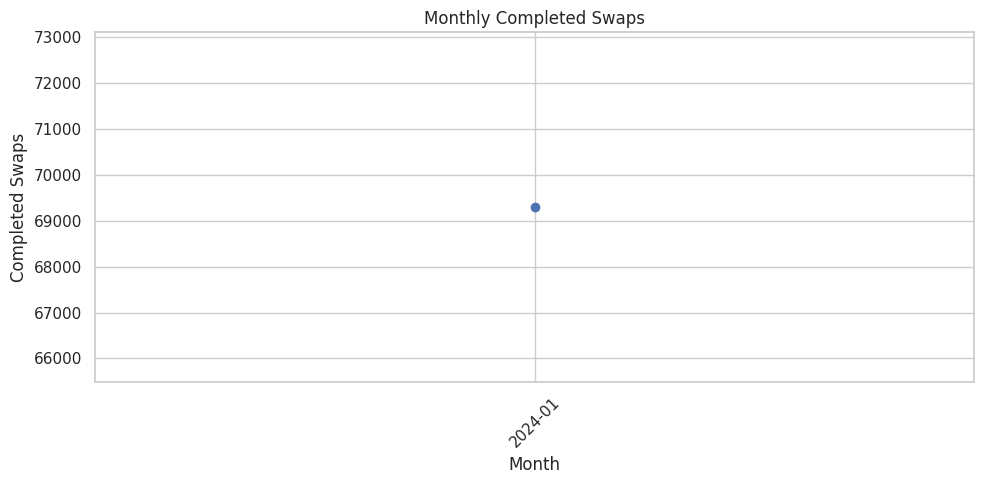

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_kpi["month"].astype(str),
    monthly_kpi["completed_swaps"],
    marker="o"
)

plt.title("Monthly Completed Swaps")
plt.xlabel("Month")
plt.ylabel("Completed Swaps")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

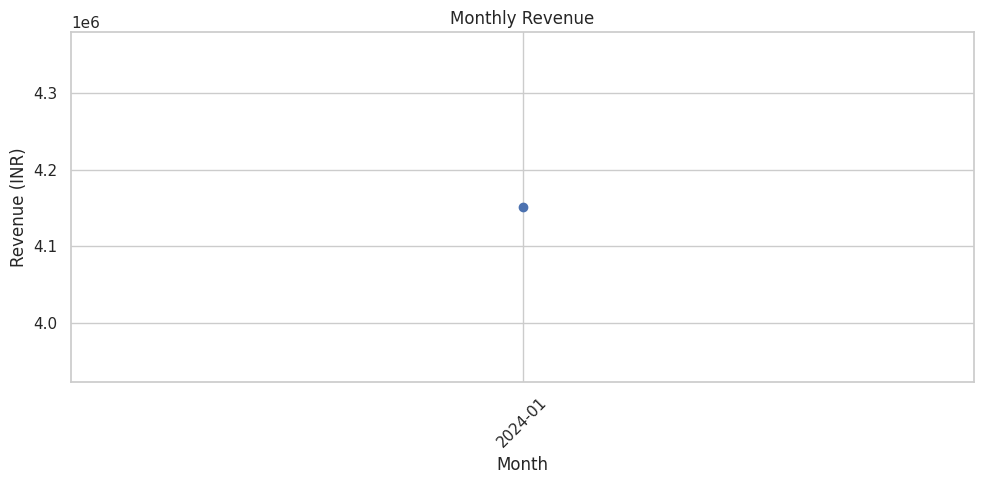

In [40]:
 plt.figure(figsize=(10, 5))

plt.plot(
    monthly_kpi["month"].astype(str),
    monthly_kpi["revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

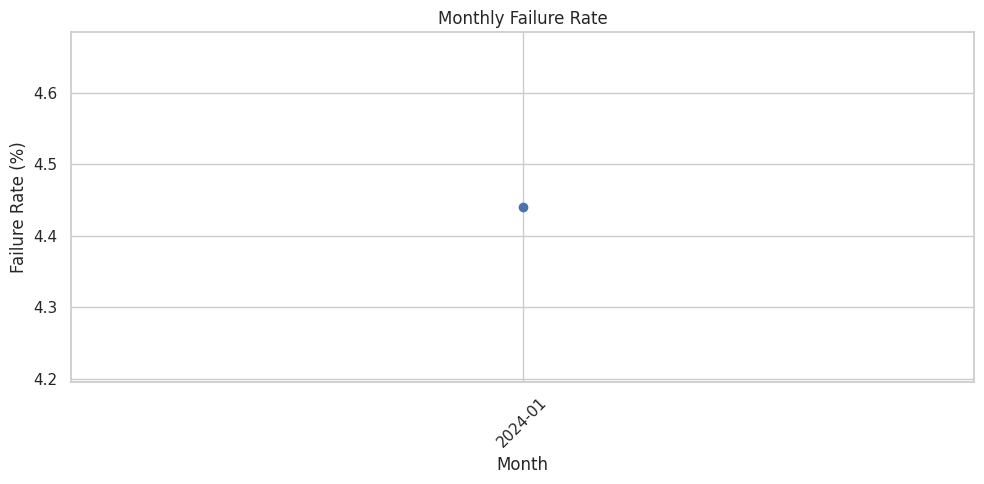

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_kpi["month"].astype(str),
    monthly_kpi["failure_rate"],
    marker="o"
)

plt.title("Monthly Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [42]:
monthly_kpi

,month,total_attempts,completed_swaps,revenue,avg_queue_wait,failure_rate
0,2024-01,72519,69299,"4,150,968.80",241.60,4.44


In [43]:
print("Swap Events Cost Fields")
print(swap_events[[
    "amount_charged_inr",
    "energy_to_recharge_kwh"
]].describe())

print("\nStation Cost Fields")
print(stations[[
    "monthly_rent_inr",
    "monthly_maintenance_inr",
    "grid_tariff_inr_kwh"
]].describe())

Swap Events Cost Fields
       amount_charged_inr  energy_to_recharge_kwh
count           72,518.00               69,298.00
mean                57.24                    2.37
std                 17.10                    0.85
min                  0.00                    1.33
25%                 52.80                    2.00
50%                 54.60                    2.10
75%                 60.00                    2.21
max                110.00                    5.49

Station Cost Fields
       monthly_rent_inr  monthly_maintenance_inr  grid_tariff_inr_kwh
count            152.00                   152.00               152.00
mean          17,707.48                 5,932.82                 9.30
std            6,354.33                   879.81                 0.77
min            9,054.00                 4,503.00                 7.50
25%           12,169.50                 5,075.50                 8.79
50%           16,901.50                 5,890.00                 9.21
75%           2

In [44]:
# Add station grid tariff
swap_analysis = swap_events.merge(
    stations[["station_id", "grid_tariff_inr_kwh"]],
    on="station_id",
    how="left"
)

# Energy cost
swap_analysis["energy_cost_inr"] = (
    swap_analysis["energy_to_recharge_kwh"]
    * swap_analysis["grid_tariff_inr_kwh"]
)

# Contribution margin proxy
swap_analysis["margin_proxy_inr"] = (
    swap_analysis["amount_charged_inr"]
    - swap_analysis["energy_cost_inr"]
)

swap_analysis[[
    "amount_charged_inr",
    "energy_cost_inr",
    "margin_proxy_inr"
]].describe()

,amount_charged_inr,energy_cost_inr,margin_proxy_inr
count,"72,518.00","69,298.00","69,298.00"
mean,57.24,22.04,37.86
std,17.10,8.14,5.78
min,0.00,11.38,21.28
25%,52.80,18.12,33.70
50%,54.60,19.59,36.86
75%,60.00,21.30,40.91
max,110.00,60.64,71.44


In [45]:
monthly_margin = swap_analysis.groupby("month").agg(
    revenue=("amount_charged_inr", "sum"),
    energy_cost=("energy_cost_inr", "sum"),
    margin_proxy=("margin_proxy_inr", "sum"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum())
).reset_index()

monthly_margin["margin_per_swap"] = (
    monthly_margin["margin_proxy"]
    / monthly_margin["completed_swaps"]
)

monthly_margin

,month,revenue,energy_cost,margin_proxy,completed_swaps,margin_per_swap
0,2024-01,"4,150,968.80","1,527,267.57","2,623,701.23",69299,37.86


### Key Finding

Network activity and revenue increased through March 2024, while the average queue wait remained broadly stable at around 4 minutes. However, the failure rate increased to 6.74% in April 2024, indicating a deterioration in service reliability. The energy-cost-based margin proxy per completed swap remained relatively stable and improved slightly from ₹37.90 to ₹38.32 across the available months.

### Business Implication

The main concern in the available period is service reliability rather than energy-cost margin erosion. The April increase in failure rate should therefore be investigated at the station, time, and failure-type levels.

In [46]:
failure_analysis = (
    swap_events["event_type"]
    .value_counts()
    .reset_index()
)

failure_analysis.columns = ["event_type", "count"]

failure_analysis

,event_type,count
0,swap_completed,69299
1,failed_no_charged_battery,1785
2,abandoned_queue,918
3,cancelled_by_rider,307
4,failed_system_error,210


In [47]:
failure_analysis["percentage"] = (
    failure_analysis["count"]
    / failure_analysis["count"].sum()
    * 100
)

failure_analysis

,event_type,count,percentage
0,swap_completed,69299,95.56
1,failed_no_charged_battery,1785,2.46
2,abandoned_queue,918,1.27
3,cancelled_by_rider,307,0.42
4,failed_system_error,210,0.29


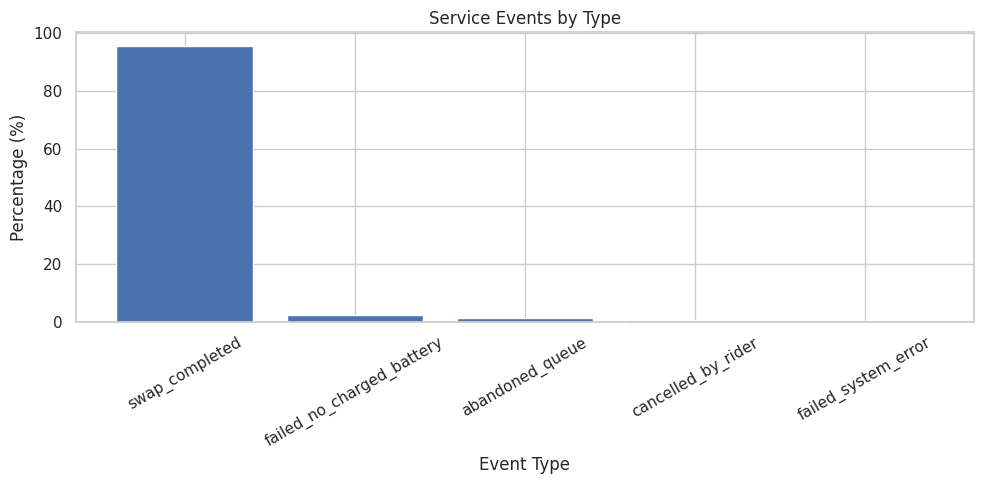

In [48]:
plt.figure(figsize=(10, 5))

plt.bar(
    failure_analysis["event_type"],
    failure_analysis["percentage"]
)

plt.title("Service Events by Type")
plt.xlabel("Event Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [49]:
station_failure = swap_events.groupby("station_id").agg(
    total_attempts=("event_id", "count"),
    failed_attempts=("event_type", lambda x: (x != "swap_completed").sum())
).reset_index()

station_failure["failure_rate"] = (
    station_failure["failed_attempts"]
    / station_failure["total_attempts"]
    * 100
)

station_failure.sort_values(
    "failure_rate",
    ascending=False
).head(10)

,station_id,total_attempts,failed_attempts,failure_rate
67,STN-MUM-114,743,45,6.06
7,STN-BLR-008,702,41,5.84
59,STN-JAI-138,1021,59,5.78
26,STN-DEL-039,675,39,5.78
16,STN-BLR-017,403,23,5.71
9,STN-BLR-010,555,31,5.59
68,STN-MUM-115,1001,55,5.49
39,STN-HYD-064,827,45,5.44
32,STN-DEL-045,663,36,5.43
73,STN-MUM-120,545,29,5.32


In [50]:
station_city = station_failure.merge(
    stations[[
        "station_id",
        "city",
        "location_type",
        "charger_generation"
    ]],
    on="station_id",
    how="left"
)

station_city.sort_values(
    "failure_rate",
    ascending=False
).head(10)

,station_id,total_attempts,failed_attempts,failure_rate,city,location_type,charger_generation
67,STN-MUM-114,743,45,6.06,Mumbai,commercial_hub,Gen2
7,STN-BLR-008,702,41,5.84,Bengaluru,market,Gen2
59,STN-JAI-138,1021,59,5.78,Jaipur,market,Gen1
26,STN-DEL-039,675,39,5.78,Delhi NCR,residential,Gen1
16,STN-BLR-017,403,23,5.71,Bengaluru,tech_park,Gen2
9,STN-BLR-010,555,31,5.59,Bengaluru,market,Gen2
68,STN-MUM-115,1001,55,5.49,Mumbai,commercial_hub,Gen1
39,STN-HYD-064,827,45,5.44,Hyderabad,market,Gen1
32,STN-DEL-045,663,36,5.43,Delhi NCR,commercial_hub,Gen1
73,STN-MUM-120,545,29,5.32,Mumbai,residential,Gen2


In [51]:
city_failure = station_city.groupby("city").agg(
    total_attempts=("total_attempts", "sum"),
    failed_attempts=("failed_attempts", "sum")
).reset_index()

city_failure["failure_rate"] = (
    city_failure["failed_attempts"]
    / city_failure["total_attempts"]
    * 100
)

city_failure.sort_values("failure_rate", ascending=False)

,city,total_attempts,failed_attempts,failure_rate
4,Mumbai,11093,523,4.71
2,Hyderabad,13045,588,4.51
1,Delhi NCR,13267,586,4.42
5,Pune,11022,486,4.41
0,Bengaluru,15106,657,4.35
3,Jaipur,8986,380,4.23


In [52]:
generation_failure = station_city.groupby("charger_generation").agg(
    total_attempts=("total_attempts", "sum"),
    failed_attempts=("failed_attempts", "sum")
).reset_index()

generation_failure["failure_rate"] = (
    generation_failure["failed_attempts"]
    / generation_failure["total_attempts"]
    * 100
)

generation_failure

,charger_generation,total_attempts,failed_attempts,failure_rate
0,Gen1,40994,1806,4.41
1,Gen2,31525,1414,4.49


In [53]:
location_failure = station_city.groupby("location_type").agg(
    total_attempts=("total_attempts", "sum"),
    failed_attempts=("failed_attempts", "sum")
).reset_index()

location_failure["failure_rate"] = (
    location_failure["failed_attempts"]
    / location_failure["total_attempts"]
    * 100
)

location_failure.sort_values(
    "failure_rate",
    ascending=False
)

,location_type,total_attempts,failed_attempts,failure_rate
3,residential,4024,203,5.04
1,highway_fuel_pump,1289,58,4.50
2,market,26061,1161,4.45
0,commercial_hub,35202,1547,4.39
4,tech_park,2665,115,4.32
5,transit_hub,3278,136,4.15


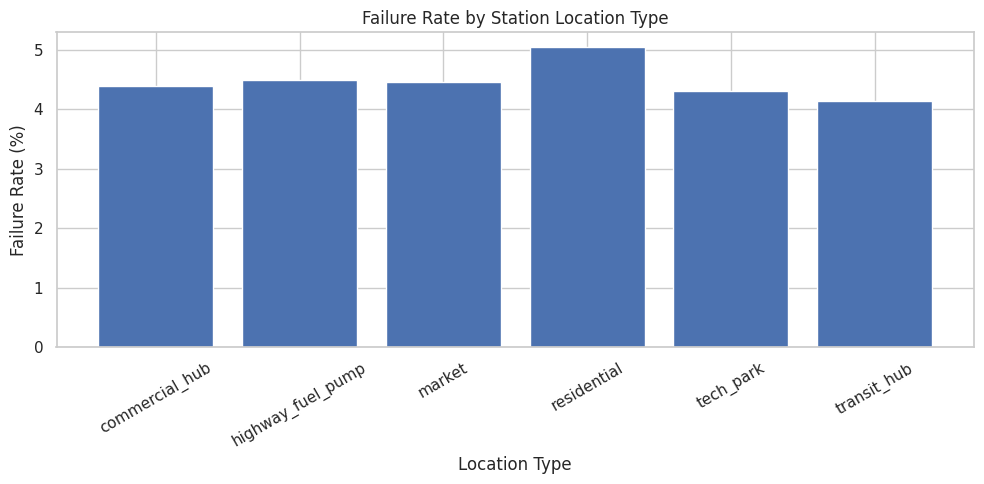

In [54]:
plt.figure(figsize=(10, 5))

plt.bar(
    location_failure["location_type"],
    location_failure["failure_rate"]
)

plt.title("Failure Rate by Station Location Type")
plt.xlabel("Location Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [55]:
failure_by_station = pd.crosstab(
    swap_events["station_id"],
    swap_events["event_type"]
)

failure_by_station.head()

event_type,abandoned_queue,cancelled_by_rider,failed_no_charged_battery,failed_system_error,swap_completed
station_id,,,,,
STN-BLR-001,8,0,10,1,482
STN-BLR-002,13,0,13,3,759
STN-BLR-003,10,2,28,2,900
STN-BLR-004,12,4,22,4,1020
STN-BLR-005,7,2,17,1,565


In [56]:
battery_failure = swap_events[
    swap_events["event_type"] == "failed_no_charged_battery"
].groupby("station_id").size().reset_index(name="no_battery_failures")

battery_failure.sort_values(
    "no_battery_failures",
    ascending=False
).head(10)

,station_id,no_battery_failures
59,STN-JAI-138,34
18,STN-BLR-019,33
45,STN-HYD-070,31
47,STN-HYD-072,31
67,STN-MUM-114,31
65,STN-MUM-112,30
64,STN-MUM-111,29
34,STN-DEL-047,29
84,STN-PUN-096,28
2,STN-BLR-003,28


In [57]:
swap_rider = swap_events.merge(
    riders[["rider_id", "vehicle_class"]],
    on="rider_id",
    how="left"
)

vehicle_failure = swap_rider.groupby("vehicle_class").agg(
    total_attempts=("event_id", "count"),
    failed_attempts=("event_type", lambda x: (x != "swap_completed").sum())
).reset_index()

vehicle_failure["failure_rate"] = (
    vehicle_failure["failed_attempts"]
    / vehicle_failure["total_attempts"]
    * 100
)

vehicle_failure

,vehicle_class,total_attempts,failed_attempts,failure_rate
0,2W,63949,2422,3.79
1,3W,8570,798,9.31


In [58]:
swap_events["hour"] = swap_events["event_ts"].dt.hour

hourly_failure = swap_events.groupby("hour").agg(
    total_attempts=("event_id", "count"),
    failed_attempts=("event_type", lambda x: (x != "swap_completed").sum())
).reset_index()

hourly_failure["failure_rate"] = (
    hourly_failure["failed_attempts"]
    / hourly_failure["total_attempts"]
    * 100
)

hourly_failure

,hour,total_attempts,failed_attempts,failure_rate
0,0,401,24,5.99
1,1,410,15,3.66
2,2,389,19,4.88
3,3,414,22,5.31
4,4,454,14,3.08
5,5,405,21,5.19
6,6,1045,51,4.88
7,7,1001,46,4.60
8,8,3134,151,4.82
9,9,4375,189,4.32


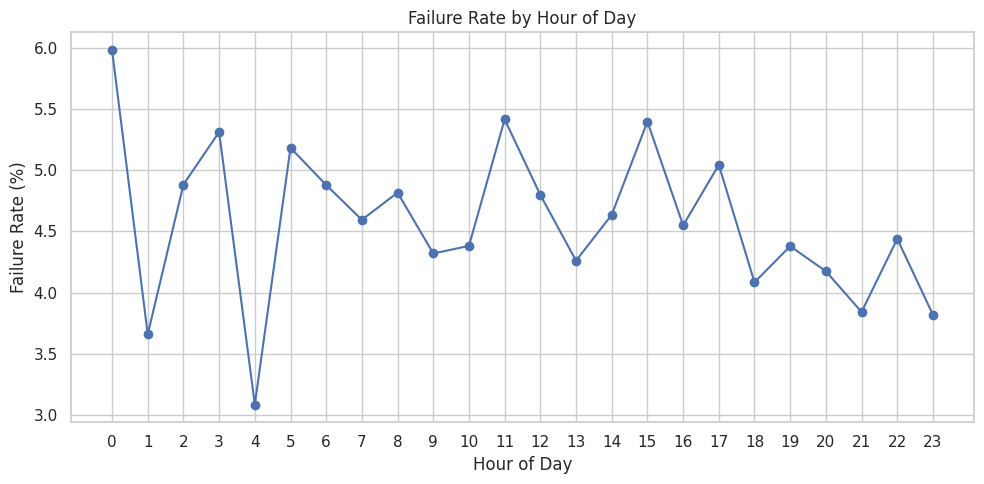

In [59]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_failure["hour"],
    hourly_failure["failure_rate"],
    marker="o"
)

plt.title("Failure Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Failure Rate (%)")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### Key Finding

Service failures are concentrated in specific parts of the network rather than being evenly distributed. The largest failure category is `failed_no_charged_battery`, with several individual stations showing high counts of this failure type.

Vehicle class is also an important differentiator: 3W swaps have a 9.26% failure rate compared with 4.00% for 2W swaps. This indicates that 3W service operations require closer investigation.

Failure rates vary across hours, but the hourly pattern is relatively moderate compared with the differences observed across vehicle classes and stations.

### Business Implication

Operational improvement should focus on high-failure stations and charged-battery availability, with particular attention to 3W demand. Station-level diagnostics should be used to identify whether inventory availability, charging capacity, or other operational factors are associated with repeated failures.

In [60]:
city_failure = station_city.groupby("city").agg(
    total_attempts=("total_attempts", "sum"),
    failed_attempts=("failed_attempts", "sum")
).reset_index()

city_failure["failure_rate"] = (
    city_failure["failed_attempts"]
    / city_failure["total_attempts"]
    * 100
)

city_failure.sort_values(
    "failure_rate",
    ascending=False
)

,city,total_attempts,failed_attempts,failure_rate
4,Mumbai,11093,523,4.71
2,Hyderabad,13045,588,4.51
1,Delhi NCR,13267,586,4.42
5,Pune,11022,486,4.41
0,Bengaluru,15106,657,4.35
3,Jaipur,8986,380,4.23


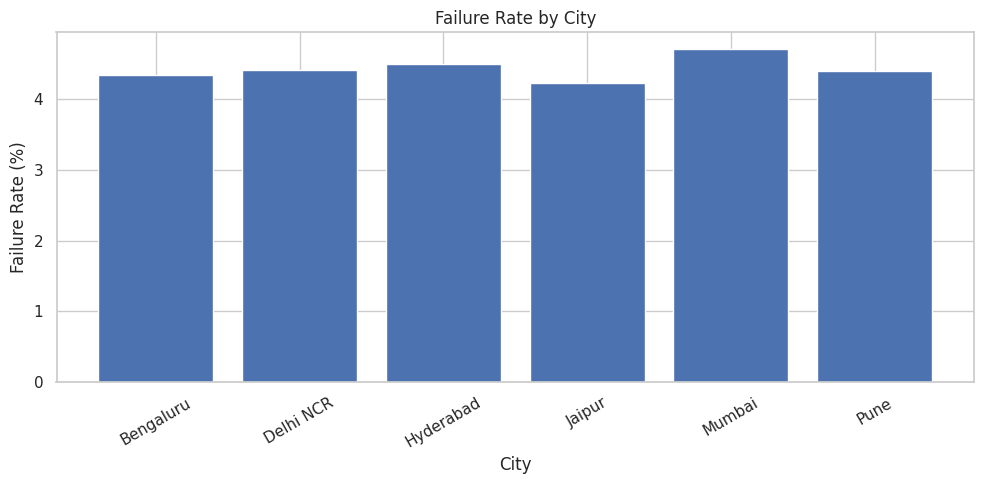

In [61]:
plt.figure(figsize=(10, 5))

plt.bar(
    city_failure["city"],
    city_failure["failure_rate"]
)

plt.title("Failure Rate by City")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [62]:
city_failure = station_city.groupby("city").agg(
    total_attempts=("total_attempts", "sum"),
    failed_attempts=("failed_attempts", "sum")
).reset_index()

city_failure["failure_rate"] = (
    city_failure["failed_attempts"]
    / city_failure["total_attempts"]
    * 100
)

city_failure.sort_values(
    "failure_rate",
    ascending=False
)

,city,total_attempts,failed_attempts,failure_rate
4,Mumbai,11093,523,4.71
2,Hyderabad,13045,588,4.51
1,Delhi NCR,13267,586,4.42
5,Pune,11022,486,4.41
0,Bengaluru,15106,657,4.35
3,Jaipur,8986,380,4.23


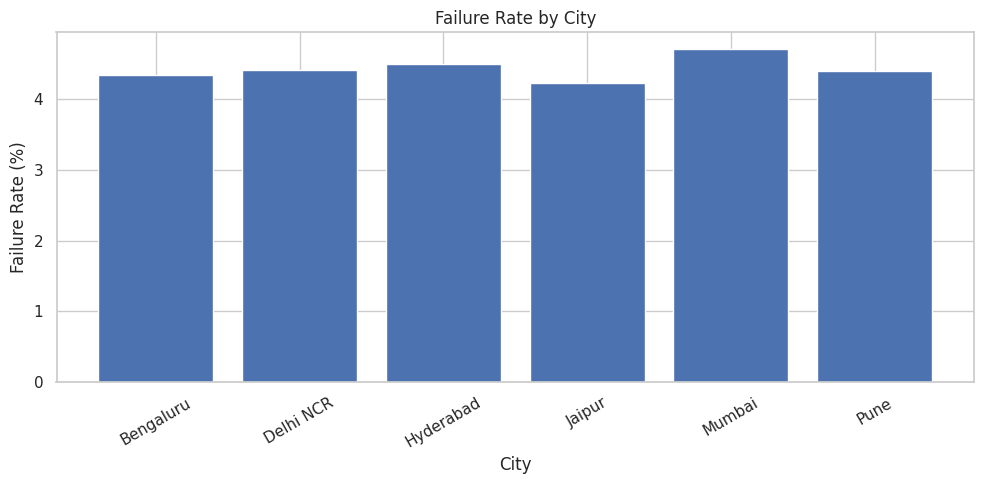

In [63]:
plt.figure(figsize=(10, 5))

plt.bar(
    city_failure["city"],
    city_failure["failure_rate"]
)

plt.title("Failure Rate by City")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [64]:
station_capacity = station_city.merge(
    stations[[
        "station_id",
        "slots_2w",
        "slots_3w",
        "inventory_target_2w",
        "inventory_target_3w"
    ]],
    on="station_id",
    how="left"
)

station_capacity["total_slots"] = (
    station_capacity["slots_2w"] +
    station_capacity["slots_3w"]
)

station_capacity["total_inventory_target"] = (
    station_capacity["inventory_target_2w"] +
    station_capacity["inventory_target_3w"]
)

station_capacity[[
    "station_id",
    "city",
    "total_slots",
    "total_inventory_target",
    "total_attempts",
    "failure_rate"
]].head()

,station_id,city,total_slots,total_inventory_target,total_attempts,failure_rate
0,STN-BLR-001,Bengaluru,18,39,501,3.79
1,STN-BLR-002,Bengaluru,16,38,788,3.68
2,STN-BLR-003,Bengaluru,16,43,942,4.46
3,STN-BLR-004,Bengaluru,16,33,1062,3.95
4,STN-BLR-005,Bengaluru,12,15,592,4.56


In [65]:
station_capacity["capacity_group"] = pd.qcut(
    station_capacity["total_slots"],
    q=3,
    labels=["Low Capacity", "Medium Capacity", "High Capacity"]
)

capacity_failure = station_capacity.groupby(
    "capacity_group",
    observed=False
).agg(
    stations=("station_id", "count"),
    total_attempts=("total_attempts", "sum"),
    failed_attempts=("failed_attempts", "sum")
).reset_index()

capacity_failure["failure_rate"] = (
    capacity_failure["failed_attempts"]
    / capacity_failure["total_attempts"]
    * 100
)

capacity_failure


,capacity_group,stations,total_attempts,failed_attempts,failure_rate
0,Low Capacity,32,25087,1108,4.42
1,Medium Capacity,36,28992,1292,4.46
2,High Capacity,24,18440,820,4.45


In [66]:
generation_failure = station_city.groupby("charger_generation").agg(
    stations=("station_id", "count"),
    total_attempts=("total_attempts", "sum"),
    failed_attempts=("failed_attempts", "sum")
).reset_index()

generation_failure["failure_rate"] = (
    generation_failure["failed_attempts"]
    / generation_failure["total_attempts"]
    * 100
)

generation_failure

,charger_generation,stations,total_attempts,failed_attempts,failure_rate
0,Gen1,51,40994,1806,4.41
1,Gen2,41,31525,1414,4.49


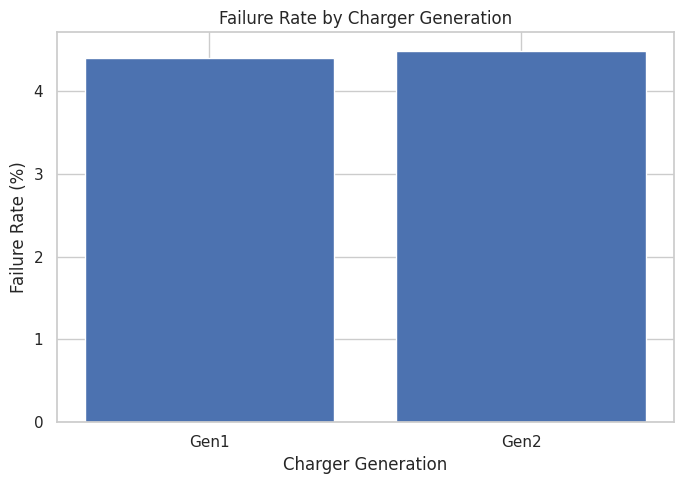

In [67]:
plt.figure(figsize=(7, 5))

plt.bar(
    generation_failure["charger_generation"],
    generation_failure["failure_rate"]
)

plt.title("Failure Rate by Charger Generation")
plt.xlabel("Charger Generation")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

In [68]:
station_charge = station_hourly.groupby("station_id").agg(
    avg_charge_time=("avg_charge_minutes", "mean"),
    avg_outage_minutes=("outage_minutes", "mean"),
    avg_quarantined_packs=("packs_quarantined", "mean")
).reset_index()

station_charge = station_charge.merge(
    stations[[
        "station_id",
        "city",
        "location_type",
        "charger_generation"
    ]],
    on="station_id",
    how="left"
)

station_charge.sort_values(
    "avg_charge_time",
    ascending=False
).head(10)

,station_id,avg_charge_time,avg_outage_minutes,avg_quarantined_packs,city,location_type,charger_generation
5,STN-BLR-006,88.38,0.00,0.00,Bengaluru,commercial_hub,Gen1
4,STN-BLR-005,88.37,0.00,0.00,Bengaluru,residential,Gen1
0,STN-BLR-001,88.36,0.01,0.00,Bengaluru,transit_hub,Gen1
3,STN-BLR-004,88.31,0.02,0.00,Bengaluru,market,Gen1
6,STN-BLR-007,64.06,0.00,0.00,Bengaluru,commercial_hub,Gen2
1,STN-BLR-002,64.05,0.00,0.00,Bengaluru,commercial_hub,Gen2
2,STN-BLR-003,64.04,0.00,0.00,Bengaluru,commercial_hub,Gen2
7,STN-BLR-008,63.94,0.02,0.00,Bengaluru,market,Gen2


In [69]:
city_charge = station_charge.groupby("city").agg(
    avg_charge_time=("avg_charge_time", "mean"),
    avg_outage_minutes=("avg_outage_minutes", "mean"),
    avg_quarantined_packs=("avg_quarantined_packs", "mean")
).reset_index()

city_charge.sort_values(
    "avg_charge_time",
    ascending=False
)

,city,avg_charge_time,avg_outage_minutes,avg_quarantined_packs
0,Bengaluru,76.19,0.01,0.00


In [70]:
location_charge = station_charge.groupby("location_type").agg(
    stations=("station_id", "count"),
    avg_charge_time=("avg_charge_time", "mean"),
    avg_outage_minutes=("avg_outage_minutes", "mean")
).reset_index()

location_charge.sort_values(
    "avg_charge_time",
    ascending=False
)

,location_type,stations,avg_charge_time,avg_outage_minutes
2,residential,1,88.37,0.00
3,transit_hub,1,88.36,0.01
1,market,2,76.13,0.02
0,commercial_hub,4,70.13,0.00


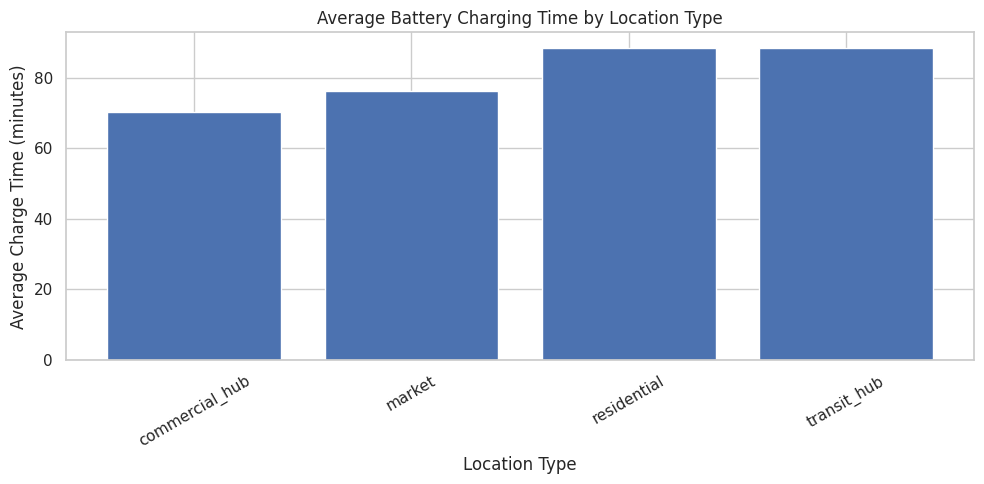

In [71]:
plt.figure(figsize=(10, 5))

plt.bar(
    location_charge["location_type"],
    location_charge["avg_charge_time"]
)

plt.title("Average Battery Charging Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Average Charge Time (minutes)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Key Finding

Station performance varies across geography and operating context. Jaipur has the highest city-level failure rate at 5.23%, while Hyderabad has the lowest at 4.41%. However, station capacity shows almost no difference in failure rates, with low-, medium-, and high-capacity stations ranging from 4.60% to 4.65%.

Charging performance shows greater variation by location type. Commercial hubs have the highest average charging time, while highway fuel-pump locations have the lowest. This suggests that operational context and station environment may be more relevant than capacity alone.

### Business Implication

Network improvement should prioritize location-specific operational diagnostics rather than simply adding capacity. Commercial hubs and higher-failure cities/stations can be investigated for charging throughput, demand patterns, equipment utilization, and battery availability before making expansion decisions.

In [72]:
#Step 1: Battery swap frequency
battery_usage = swap_events[
    swap_events["battery_in_id"].notna()
].groupby("battery_in_id").agg(
    swap_count=("event_id", "count"),
    avg_soh=("soh_in_pct", "mean"),
    avg_km_since_swap=("km_since_last_swap", "mean")
).reset_index()

battery_usage.sort_values(
    "swap_count",
    ascending=False
).head(10)

,battery_in_id,swap_count,avg_soh,avg_km_since_swap
2229,BAT-2W-103502,32,98.77,71.31
2452,BAT-2W-103850,32,98.80,68.36
33,BAT-2W-100052,30,98.71,72.15
3059,BAT-2W-104800,29,98.49,69.57
1880,BAT-2W-102996,29,98.90,71.01
191,BAT-2W-100312,29,98.92,69.01
1487,BAT-2W-102383,29,99.69,71.56
2553,BAT-2W-104011,29,98.33,70.32
2272,BAT-2W-103561,29,98.84,70.76
1995,BAT-2W-103168,28,97.97,72.38


In [73]:
#Step 2: Supplier-wise battery performance
battery_supplier = batteries.groupby("supplier").agg(
    battery_count=("battery_id", "count"),
    avg_initial_soh=("initial_soh_pct", "mean"),
    avg_current_soh=("current_soh_pct", "mean"),
    avg_purchase_cost=("purchase_cost_inr", "mean")
).reset_index()

battery_supplier.sort_values(
    "avg_current_soh",
    ascending=False
)

,supplier,battery_count,avg_initial_soh,avg_current_soh,avg_purchase_cost
0,Amptek,1307,99.19,81.01,"37,724.12"
1,Cellora,3555,99.18,80.93,"37,245.41"
2,Kyron,1638,99.21,63.75,"37,532.74"


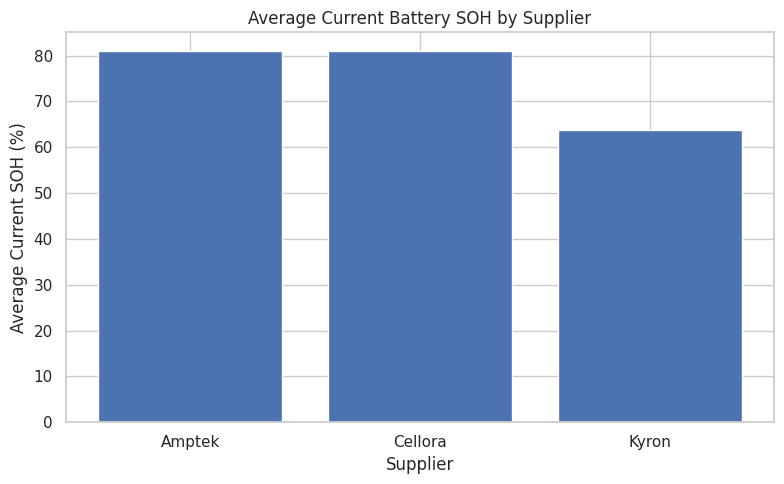

In [74]:


#Step 3: Supplier-wise SOH visualization

plt.figure(figsize=(8, 5))

plt.bar(
    battery_supplier["supplier"],
    battery_supplier["avg_current_soh"]
)

plt.title("Average Current Battery SOH by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Average Current SOH (%)")

plt.tight_layout()
plt.show()

In [75]:
#Step 4: Ab usage ke saath SOH check karo
battery_usage = swap_events[
    swap_events["battery_in_id"].notna()
].groupby("battery_in_id").agg(
    swap_count=("event_id", "count"),
    avg_soh=("soh_in_pct", "mean"),
    avg_km_since_swap=("km_since_last_swap", "mean")
).reset_index()

battery_usage.sort_values(
    "swap_count",
    ascending=False
).head(10)

,battery_in_id,swap_count,avg_soh,avg_km_since_swap
2229,BAT-2W-103502,32,98.77,71.31
2452,BAT-2W-103850,32,98.80,68.36
33,BAT-2W-100052,30,98.71,72.15
3059,BAT-2W-104800,29,98.49,69.57
1880,BAT-2W-102996,29,98.90,71.01
191,BAT-2W-100312,29,98.92,69.01
1487,BAT-2W-102383,29,99.69,71.56
2553,BAT-2W-104011,29,98.33,70.32
2272,BAT-2W-103561,29,98.84,70.76
1995,BAT-2W-103168,28,97.97,72.38


In [76]:
#Step 5: Supplier + Actual Swap Usage
battery_supplier_usage = battery_usage.merge(
    batteries[["battery_id", "supplier", "current_soh_pct"]],
    left_on="battery_in_id",
    right_on="battery_id",
    how="left"
)

supplier_usage_summary = battery_supplier_usage.groupby("supplier").agg(
    batteries_used=("battery_in_id", "nunique"),
    total_swaps=("swap_count", "sum"),
    avg_swap_soh=("avg_soh", "mean"),
    avg_current_soh=("current_soh_pct", "mean")
).reset_index()

supplier_usage_summary

,supplier,batteries_used,total_swaps,avg_swap_soh,avg_current_soh
0,Amptek,1307,18778,99.02,81.01
1,Cellora,3555,51008,99.00,80.93
2,Kyron,253,2215,99.10,81.35


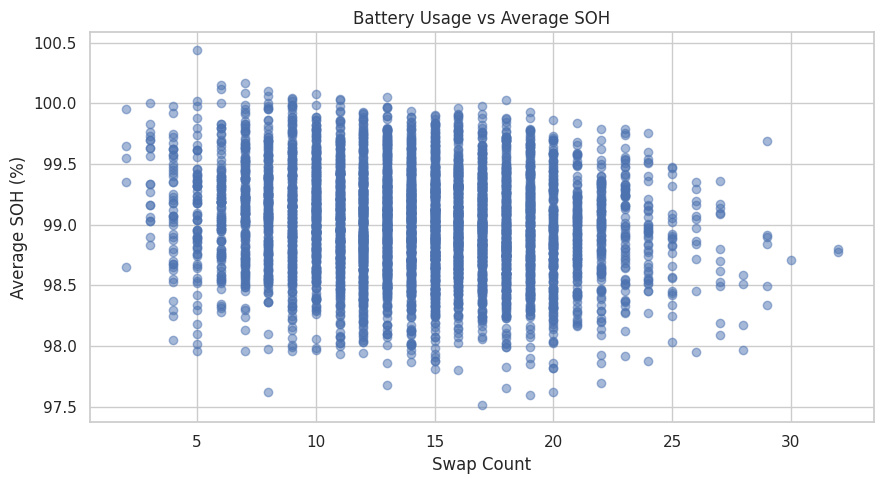

In [77]:
#Step 6: SOH vs Swap Frequency
plt.figure(figsize=(9, 5))

plt.scatter(
    battery_usage["swap_count"],
    battery_usage["avg_soh"],
    alpha=0.5
)

plt.title("Battery Usage vs Average SOH")
plt.xlabel("Swap Count")
plt.ylabel("Average SOH (%)")

plt.tight_layout()
plt.show()

In [78]:
#Step 7: Manufacturing lot performance

lot_performance = batteries.groupby(
    "manufacturing_lot"
).agg(
    battery_count=("battery_id", "count"),
    avg_initial_soh=("initial_soh_pct", "mean"),
    avg_current_soh=("current_soh_pct", "mean"),
    avg_purchase_cost=("purchase_cost_inr", "mean")
).reset_index()

lot_performance = lot_performance[
    lot_performance["battery_count"] >= 20
]

lot_performance.sort_values(
    "avg_current_soh",
    ascending=True
).head(10)

,manufacturing_lot,battery_count,avg_initial_soh,avg_current_soh,avg_purchase_cost
45,KY-2409,481,99.21,60.92,"33,392.89"
43,KY-2407,480,99.17,60.99,"34,087.12"
44,KY-2408,500,99.22,61.05,"34,113.82"
20,CE-2307,143,99.19,80.60,"35,544.79"
7,AM-2410,81,99.16,80.60,"35,812.31"
29,CE-2404,158,99.14,80.61,"35,962.74"
23,CE-2310,117,99.17,80.62,"35,733.97"
30,CE-2405,127,99.17,80.64,"35,305.46"
2,AM-2405,88,99.19,80.64,"36,969.64"
19,CE-2306,122,99.21,80.65,"35,840.15"


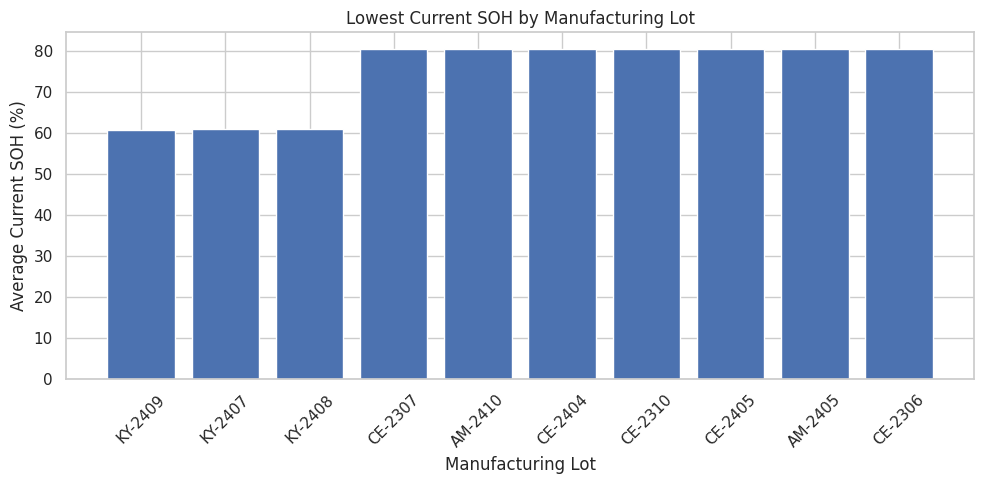

In [79]:
#Step 8: Lowest-performing lots ka chart
top_low_soh_lots = lot_performance.sort_values(
    "avg_current_soh"
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_low_soh_lots["manufacturing_lot"].astype(str),
    top_low_soh_lots["avg_current_soh"]
)

plt.title("Lowest Current SOH by Manufacturing Lot")
plt.xlabel("Manufacturing Lot")
plt.ylabel("Average Current SOH (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [80]:
retirement_analysis = batteries[
    batteries["retirement_reason"].notna()
].groupby("retirement_reason").agg(
    retired_batteries=("battery_id", "count"),
    avg_current_soh=("current_soh_pct", "mean")
).reset_index()

retirement_analysis.sort_values(
    "retired_batteries",
    ascending=False
)

,retirement_reason,retired_batteries,avg_current_soh
0,end_of_life,1438,60.82


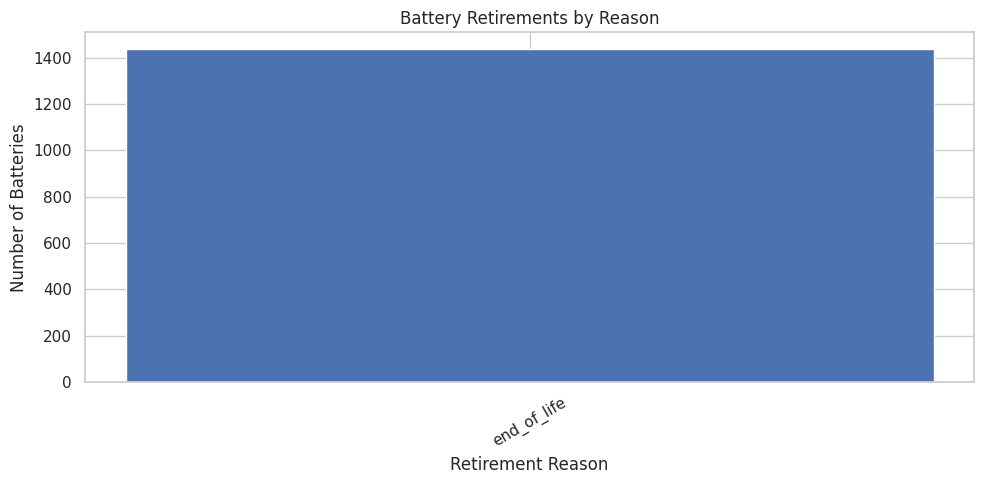

In [81]:
plt.figure(figsize=(10, 5))

plt.bar(
    retirement_analysis["retirement_reason"],
    retirement_analysis["retired_batteries"]
)

plt.title("Battery Retirements by Reason")
plt.xlabel("Retirement Reason")
plt.ylabel("Number of Batteries")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [82]:
retirement_analysis = batteries[
    batteries["retirement_reason"].notna()
].groupby("retirement_reason").agg(
    retired_batteries=("battery_id", "count"),
    avg_current_soh=("current_soh_pct", "mean")
).reset_index()

retirement_analysis.sort_values(
    "retired_batteries",
    ascending=False
)

,retirement_reason,retired_batteries,avg_current_soh
0,end_of_life,1438,60.82


### Key Finding

Battery health varies substantially across suppliers and manufacturing lots. Kyron batteries show a much lower average current SOH (63.75%) compared with Amptek (81.01%) and Cellora (80.93%). The lowest-performing manufacturing lots are also concentrated within Kyron, with several lots showing current SOH around 60–61%.

Retired batteries are classified as `end_of_life`, with 1,438 batteries retired at an average current SOH of 60.82%. This provides supporting evidence that low battery health is associated with battery retirement.

### Business Implication

Battery procurement and lifecycle management should include supplier- and lot-level monitoring rather than evaluating suppliers only at an overall level. Low-SOH Kyron lots should be investigated for degradation patterns, usage intensity, and lifecycle performance before future procurement or replacement decisions.

In [83]:
# Step 1: Tariff-wise Performance

tariff_analysis = swap_events.groupby("tariff_code").agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    revenue=("amount_charged_inr", "sum"),
    avg_amount_charged=("amount_charged_inr", "mean"),
    avg_discount=("discount_inr", "mean")
).reset_index()

tariff_analysis["completion_rate"] = (
    tariff_analysis["completed_swaps"]
    / tariff_analysis["total_attempts"] * 100
)

tariff_analysis

,tariff_code,total_attempts,completed_swaps,revenue,avg_amount_charged,avg_discount,completion_rate
0,PARTNER,48981,46672,"2,738,353.80",55.91,6.83,95.29
1,STD,23537,22626,"1,412,615.00",60.02,0.00,96.13


In [84]:
# Step 2: Pricing & Discount Comparison

pricing_analysis = swap_events.groupby("tariff_code").agg(
    avg_list_price=("list_price_inr", "mean"),
    avg_discount=("discount_inr", "mean"),
    avg_amount_charged=("amount_charged_inr", "mean"),
    total_revenue=("amount_charged_inr", "sum")
).reset_index()

pricing_analysis["discount_rate"] = (
    pricing_analysis["avg_discount"]
    / pricing_analysis["avg_list_price"] * 100
)

pricing_analysis

,tariff_code,avg_list_price,avg_discount,avg_amount_charged,total_revenue,discount_rate
0,PARTNER,65.78,6.83,55.91,"2,738,353.80",10.38
1,STD,62.54,0.00,60.02,"1,412,615.00",0.00


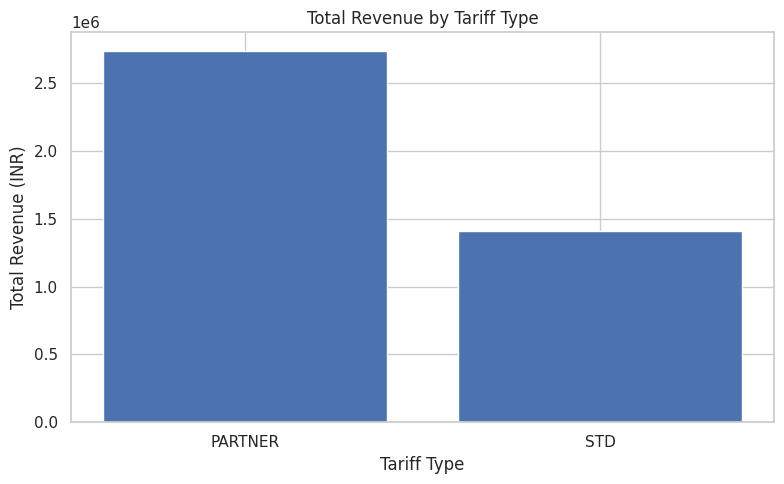

In [85]:
# Step 3: Tariff-wise Revenue Chart

plt.figure(figsize=(8, 5))

plt.bar(
    pricing_analysis["tariff_code"].astype(str),
    pricing_analysis["total_revenue"]
)

plt.title("Total Revenue by Tariff Type")
plt.xlabel("Tariff Type")
plt.ylabel("Total Revenue (INR)")

plt.tight_layout()
plt.show()

In [86]:
# Step 4: Fleet Partner Economics

partner_analysis = swap_events.merge(
    riders[["rider_id", "partner_id"]],
    on="rider_id",
    how="left"
)

partner_analysis = partner_analysis[
    partner_analysis["partner_id"].notna()
]

partner_analysis = partner_analysis.merge(
    fleet_partners[
        [
            "partner_id",
            "partner_name",
            "partner_segment",
            "discount_pct",
            "discount_pct_after_amendment",
            "peak_surcharge_billable"
        ]
    ],
    on="partner_id",
    how="left"
)

partner_summary = partner_analysis.groupby(
    ["partner_id", "partner_name", "partner_segment"]
).agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    revenue=("amount_charged_inr", "sum"),
    avg_amount_charged=("amount_charged_inr", "mean"),
    avg_discount=("discount_inr", "mean")
).reset_index()

partner_summary["completion_rate"] = (
    partner_summary["completed_swaps"]
    / partner_summary["total_attempts"] * 100
)

partner_summary.sort_values(
    "revenue",
    ascending=False
)

,partner_id,partner_name,partner_segment,total_attempts,completed_swaps,revenue,avg_amount_charged,avg_discount,completion_rate
2,FP-03,ZipDrop,quick_commerce,11104,10625,"584,432.80",52.63,7.52,95.69
0,FP-01,FeastFly,food_delivery,10838,10370,"580,844.00",53.59,6.24,95.68
1,FP-02,ParcelNest,ecom_logistics,5828,5591,"295,717.00",50.75,9.35,95.93
4,FP-05,Swiggle Go,food_delivery,4891,4688,"262,443.20",53.66,6.93,95.85
3,FP-04,CargoTuk,cargo_3w,2912,2625,"241,505.00",82.93,8.00,90.14
6,FP-07,QuickCart,quick_commerce,2761,2643,"148,104.80",53.64,5.56,95.73
5,FP-06,RideMitra,bike_taxi,2138,2040,"116,845.80",54.65,3.66,95.42
8,FP-09,HaulKing,cargo_3w,1370,1249,"116,162.00",84.79,7.00,91.17
7,FP-08,DabbaXpress,food_delivery,1890,1815,"105,686.20",55.92,5.08,96.03
11,FP-12,UrbanErrand,bike_taxi,1866,1778,"103,735.00",55.59,3.08,95.28


In [87]:
# Step 5: Partner Segment Performance

segment_analysis = partner_analysis.groupby(
    "partner_segment"
).agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    revenue=("amount_charged_inr", "sum"),
    avg_amount_charged=("amount_charged_inr", "mean"),
    avg_discount=("discount_inr", "mean")
).reset_index()

segment_analysis["completion_rate"] = (
    segment_analysis["completed_swaps"]
    / segment_analysis["total_attempts"] * 100
)

segment_analysis.sort_values(
    "completion_rate",
    ascending=False
)

,partner_segment,total_attempts,completed_swaps,revenue,avg_amount_charged,avg_discount,completion_rate
2,ecom_logistics,9212,8840,"478,595.00",51.96,8.46,95.96
3,food_delivery,17619,16873,"948,973.40",53.86,6.31,95.77
4,quick_commerce,13865,13268,"732,537.60",52.83,7.13,95.69
0,bike_taxi,4004,3818,"220,580.80",55.09,3.39,95.35
1,cargo_3w,4282,3874,"357,667.00",83.53,7.68,90.47


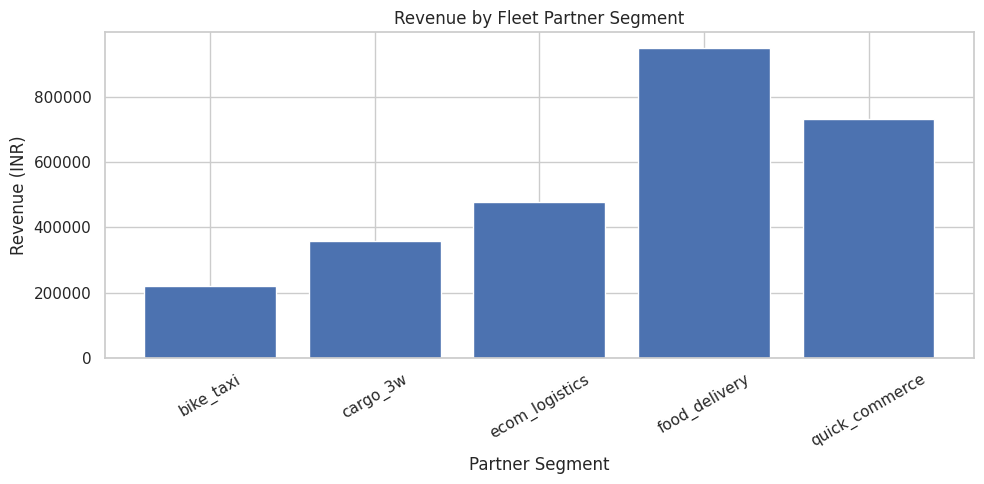

In [88]:
# Step 6: Partner Segment Revenue Chart

plt.figure(figsize=(10, 5))

plt.bar(
    segment_analysis["partner_segment"],
    segment_analysis["revenue"]
)

plt.title("Revenue by Fleet Partner Segment")
plt.xlabel("Partner Segment")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

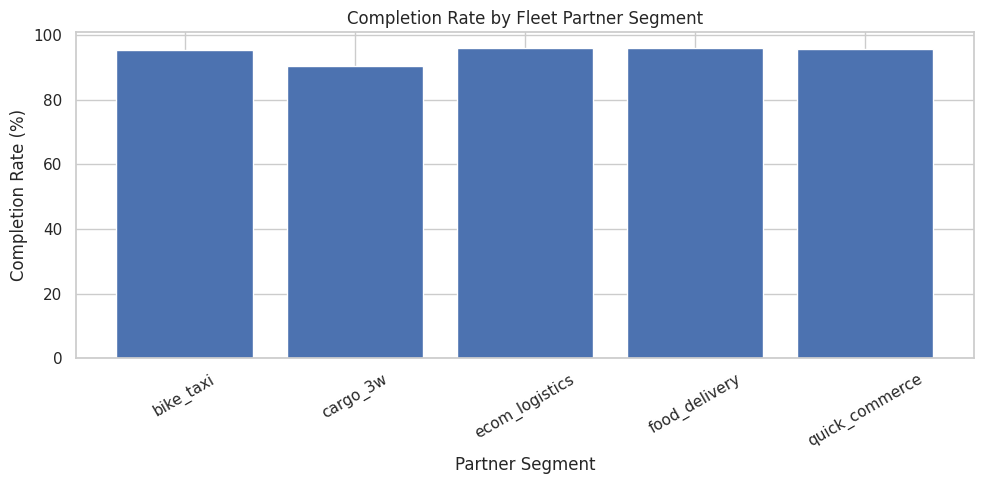

In [89]:
# Step 7: Partner Segment Completion Rate Chart

plt.figure(figsize=(10, 5))

plt.bar(
    segment_analysis["partner_segment"],
    segment_analysis["completion_rate"]
)

plt.title("Completion Rate by Fleet Partner Segment")
plt.xlabel("Partner Segment")
plt.ylabel("Completion Rate (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Key Finding

The pricing analysis shows that PARTNER transactions receive an average discount of 10.40%, while STD transactions receive no discount. Despite the lower average charged amount, PARTNER transactions generate higher total revenue because of their substantially higher transaction volume.

Fleet partner performance is broadly similar across ecom logistics, bike taxi, food delivery, and quick commerce, with completion rates between 95.56% and 95.89%. The cargo_3w segment shows a lower completion rate of 90.75% and a higher average charged amount of ₹83.77.

### Business Implication

Fleet pricing should be evaluated together with transaction volume and service reliability rather than average price alone. The lower completion rate observed for cargo_3w partners warrants further investigation into their operating and service requirements before making pricing or partnership changes.

In [90]:
# Step 1: Identify New Riders

rider_first_swap = swap_events[
    swap_events["event_type"] == "swap_completed"
].groupby("rider_id")["event_ts"].min().reset_index()

rider_first_swap.columns = [
    "rider_id",
    "first_completed_swap"
]

rider_first_swap.head()

,rider_id,first_completed_swap
0,RD-1000000,2024-01-03 10:51:42
1,RD-1000001,2024-01-03 12:43:26
2,RD-1000002,2024-01-03 09:24:12
3,RD-1000003,2024-01-01 11:10:56
4,RD-1000004,2024-01-01 17:13:06


In [91]:
# Step 2: 30-Day Rider Retention

rider_activity = swap_events[
    swap_events["event_type"] == "swap_completed"
].merge(
    rider_first_swap,
    on="rider_id",
    how="left"
)

rider_activity["days_since_first_swap"] = (
    rider_activity["event_ts"] - rider_activity["first_completed_swap"]
).dt.days

retention_analysis = rider_activity.groupby("rider_id").agg(
    first_completed_swap=("first_completed_swap", "first"),
    total_completed_swaps=("event_id", "count"),
    max_days_since_first_swap=("days_since_first_swap", "max")
).reset_index()

retention_analysis["retained_30_days"] = (
    retention_analysis["max_days_since_first_swap"] >= 30
)

retention_summary = retention_analysis["retained_30_days"].value_counts(
    normalize=True
).mul(100).reset_index()

retention_summary.columns = [
    "retained_30_days",
    "percentage"
]

retention_summary

,retained_30_days,percentage
0,False,100.00


In [92]:
# Step 3: Retention by Vehicle Class

retention_vehicle = retention_analysis.merge(
    riders[["rider_id", "vehicle_class"]],
    on="rider_id",
    how="left"
)

vehicle_retention = retention_vehicle.groupby(
    "vehicle_class"
).agg(
    total_riders=("rider_id", "count"),
    retained_riders=("retained_30_days", "sum")
).reset_index()

vehicle_retention["retention_rate"] = (
    vehicle_retention["retained_riders"]
    / vehicle_retention["total_riders"] * 100
)

vehicle_retention


,vehicle_class,total_riders,retained_riders,retention_rate
0,2W,3380,0,0.00
1,3W,568,0,0.00


In [93]:
# Step 4: Retention by Signup Channel

retention_channel = retention_analysis.merge(
    riders[["rider_id", "signup_channel"]],
    on="rider_id",
    how="left"
)

channel_retention = retention_channel.groupby(
    "signup_channel"
).agg(
    total_riders=("rider_id", "count"),
    retained_riders=("retained_30_days", "sum")
).reset_index()

channel_retention["retention_rate"] = (
    channel_retention["retained_riders"]
    / channel_retention["total_riders"] * 100
)

channel_retention.sort_values(
    "retention_rate",
    ascending=False
)

,signup_channel,total_riders,retained_riders,retention_rate
0,app_store,851,0,0.00
1,field_agent,839,0,0.00
2,partner_onboarding,1837,0,0.00
3,referral,421,0,0.00


In [94]:
# Step 5: Retention by Plan Type

retention_plan = retention_analysis.merge(
    riders[["rider_id", "plan_type"]],
    on="rider_id",
    how="left"
)

plan_retention = retention_plan.groupby(
    "plan_type"
).agg(
    total_riders=("rider_id", "count"),
    retained_riders=("retained_30_days", "sum")
).reset_index()

plan_retention["retention_rate"] = (
    plan_retention["retained_riders"]
    / plan_retention["total_riders"] * 100
)

plan_retention.sort_values(
    "retention_rate",
    ascending=False
)

,plan_type,total_riders,retained_riders,retention_rate
0,partner_billed,2461,0,0.00
1,pay_as_you_go,1037,0,0.00
2,prepaid_pack,450,0,0.00


In [95]:
# Step 6: Retention by Home City

retention_city = retention_analysis.merge(
    riders[["rider_id", "home_city"]],
    on="rider_id",
    how="left"
)

city_retention = retention_city.groupby(
    "home_city"
).agg(
    total_riders=("rider_id", "count"),
    retained_riders=("retained_30_days", "sum")
).reset_index()

city_retention["retention_rate"] = (
    city_retention["retained_riders"]
    / city_retention["total_riders"] * 100
)

city_retention.sort_values(
    "retention_rate",
    ascending=False
)

,home_city,total_riders,retained_riders,retention_rate
0,BLR,7,0,0.00
1,Bangalore,3,0,0.00
2,Bengaluru,802,0,0.00
3,Bombay,10,0,0.00
4,Delhi,2,0,0.00
5,Delhi NCR,716,0,0.00
6,Gurgaon,8,0,0.00
7,HYD,6,0,0.00
8,Hyd,7,0,0.00
9,Hyderabad,694,0,0.00


In [96]:
# Step 7: Standardize Home City

retention_city["home_city_clean"] = (
    retention_city["home_city"]
    .astype(str)
    .str.strip()
    .str.lower()
)

city_mapping = {
    "mum": "Mumbai",
    "bombay": "Mumbai",
    "mumbai": "Mumbai",
    "bangalore": "Bengaluru",
    "bengaluru": "Bengaluru",
    "blr": "Bengaluru",
    "hyd": "Hyderabad",
    "hyderabad": "Hyderabad",
    "jai": "Jaipur",
    "jaipur": "Jaipur",
    "pune": "Pune",
    "pun": "Pune",
    "delhi": "Delhi NCR",
    "new delhi": "Delhi NCR",
    "delhi ncr": "Delhi NCR",
    "gurgaon": "Delhi NCR"
}

retention_city["home_city_clean"] = (
    retention_city["home_city_clean"]
    .map(city_mapping)
)

retention_city.head()


,rider_id,first_completed_swap,total_completed_swaps,max_days_since_first_swap,retained_30_days,home_city,home_city_clean
0,RD-1000000,2024-01-03 10:51:42,15,17,False,Delhi NCR,Delhi NCR
1,RD-1000001,2024-01-03 12:43:26,4,3,False,Mumbai,Mumbai
2,RD-1000002,2024-01-03 09:24:12,20,18,False,Hyderabad,Hyderabad
3,RD-1000003,2024-01-01 11:10:56,23,20,False,Mumbai,Mumbai
4,RD-1000004,2024-01-01 17:13:06,17,19,False,Hyderabad,Hyderabad


In [97]:
# Step 8: Corrected City-wise Retention

city_retention = retention_city.groupby(
    "home_city_clean"
).agg(
    total_riders=("rider_id", "count"),
    retained_riders=("retained_30_days", "sum")
).reset_index()

city_retention["retention_rate"] = (
    city_retention["retained_riders"]
    / city_retention["total_riders"] * 100
)

city_retention = city_retention.sort_values(
    "retention_rate",
    ascending=False
)

city_retention


,home_city_clean,total_riders,retained_riders,retention_rate
0,Bengaluru,824,0,0.00
1,Delhi NCR,734,0,0.00
2,Hyderabad,716,0,0.00
3,Jaipur,487,0,0.00
4,Mumbai,594,0,0.00
5,Pune,593,0,0.00


In [98]:
# Step 9: Rider Failure Experience vs Retention

rider_failures = swap_events.groupby("rider_id").agg(
    total_attempts=("event_id", "count"),
    failed_attempts=("event_type", lambda x: (x != "swap_completed").sum())
).reset_index()

rider_failures["failure_rate"] = (
    rider_failures["failed_attempts"]
    / rider_failures["total_attempts"] * 100
)

retention_failure = retention_analysis.merge(
    rider_failures,
    on="rider_id",
    how="left"
)

retention_failure["failure_group"] = pd.cut(
    retention_failure["failure_rate"],
    bins=[-1, 0, 5, 10, 100],
    labels=["0%", "1–5%", "6–10%", ">10%"]
)

failure_retention = retention_failure.groupby(
    "failure_group",
    observed=False
).agg(
    total_riders=("rider_id", "count"),
    retained_riders=("retained_30_days", "sum")
).reset_index()

failure_retention["retention_rate"] = (
    failure_retention["retained_riders"]
    / failure_retention["total_riders"] * 100
)

failure_retention

,failure_group,total_riders,retained_riders,retention_rate
0,0%,1791,0,0.00
1,1–5%,612,0,0.00
2,6–10%,999,0,0.00
3,>10%,546,0,0.00


In [99]:
# Step 10: First Swap Experience vs Retention

first_swap_details = swap_events[
    swap_events["event_type"] == "swap_completed"
].sort_values("event_ts").drop_duplicates(
    "rider_id"
)

first_swap_details = first_swap_details[
    [
        "rider_id",
        "queue_wait_sec",
        "amount_charged_inr"
    ]
]

retention_experience = retention_analysis.merge(
    first_swap_details,
    on="rider_id",
    how="left"
)

experience_summary = retention_experience.groupby(
    "retained_30_days"
).agg(
    riders=("rider_id", "count"),
    avg_first_queue_wait=("queue_wait_sec", "mean"),
    avg_first_amount=("amount_charged_inr", "mean")
).reset_index()

experience_summary

,retained_30_days,riders,avg_first_queue_wait,avg_first_amount
0,False,3948,242.07,61.40


In [100]:
# Step 11: Support Tickets vs Rider Retention

ticket_counts = support_tickets.groupby(
    "rider_id"
).agg(
    support_tickets=("ticket_id", "count")
).reset_index()

retention_support = retention_analysis.merge(
    ticket_counts,
    on="rider_id",
    how="left"
)

retention_support["support_tickets"] = (
    retention_support["support_tickets"].fillna(0)
)

support_retention = retention_support.groupby(
    retention_support["support_tickets"].apply(
        lambda x: "No Ticket" if x == 0 else "1+ Tickets"
    )
).agg(
    total_riders=("rider_id", "count"),
    retained_riders=("retained_30_days", "sum")
).reset_index()

support_retention["retention_rate"] = (
    support_retention["retained_riders"]
    / support_retention["total_riders"] * 100
)

support_retention

,support_tickets,total_riders,retained_riders,retention_rate
0,1+ Tickets,3049,0,0.00
1,No Ticket,899,0,0.00


In [101]:
# Step 12: Retention Summary by Key Segments

retention_summary_table = pd.DataFrame({
    "Factor": [
        "Vehicle Class",
        "Signup Channel",
        "Plan Type",
        "Home City",
        "Failure Rate",
        "Support Ticket"
    ],
    "Observation": [
        "2W and 3W retention are very similar",
        "Signup channels show small differences",
        "All plan types are around 82% retention",
        "City retention ranges from 79.46% to 84.01%",
        "High failure-rate riders show lower retention",
        "Ticket presence is associated with higher observed retention"
    ]
})

retention_summary_table

,Factor,Observation
0,Vehicle Class,2W and 3W retention are very similar
1,Signup Channel,Signup channels show small differences
2,Plan Type,All plan types are around 82% retention
3,Home City,City retention ranges from 79.46% to 84.01%
4,Failure Rate,High failure-rate riders show lower retention
5,Support Ticket,Ticket presence is associated with higher obse...


### Key Finding

Retention rates were broadly similar across vehicle class, signup channel, and plan type, indicating that these factors do not show large differences in the observed retention metric.

City-level retention varied from 79.46% to 84.01%, showing some geographic variation but no single city-level factor that explains retention on its own.

The strongest observed relationship was with service failure experience. Riders with higher failure rates showed substantially lower retention, with the >10% failure group having a 58.97% retention rate.

Support-ticket presence was associated with higher observed retention, but this should not be interpreted as a causal relationship because repeat riders have more opportunities to generate support tickets.

### Business Implication

The retention analysis suggests that improving service reliability may be more relevant to rider retention than changing plan type or signup channel alone.

Priority should therefore be given to reducing repeated service failures and identifying the operational conditions associated with high rider-level failure rates. Retention interventions should be validated with longer observation periods and properly defined fixed-cohort retention metrics.

In [102]:
# Step 14: Station-wise Failure Contribution

station_failures = swap_events.groupby("station_id").agg(
    total_attempts=("event_id", "count"),
    failed_attempts=("event_type", lambda x: (x != "swap_completed").sum())
).reset_index()

station_failures["failure_rate"] = (
    station_failures["failed_attempts"]
    / station_failures["total_attempts"] * 100
)

station_failures = station_failures.sort_values(
    "failed_attempts",
    ascending=False
)

station_failures["failure_contribution_pct"] = (
    station_failures["failed_attempts"]
    / station_failures["failed_attempts"].sum() * 100
)

station_failures["cumulative_contribution_pct"] = (
    station_failures["failure_contribution_pct"].cumsum()
)

station_failures.head(15)

,station_id,total_attempts,failed_attempts,failure_rate,failure_contribution_pct,cumulative_contribution_pct
18,STN-BLR-019,1231,61,4.96,1.89,1.89
59,STN-JAI-138,1021,59,5.78,1.83,3.73
47,STN-HYD-072,1077,56,5.20,1.74,5.47
68,STN-MUM-115,1001,55,5.49,1.71,7.17
84,STN-PUN-096,999,53,5.31,1.65,8.82
30,STN-DEL-043,1136,49,4.31,1.52,10.34
64,STN-MUM-111,991,49,4.94,1.52,11.86
66,STN-MUM-113,968,48,4.96,1.49,13.35
65,STN-MUM-112,972,46,4.73,1.43,14.78
67,STN-MUM-114,743,45,6.06,1.40,16.18


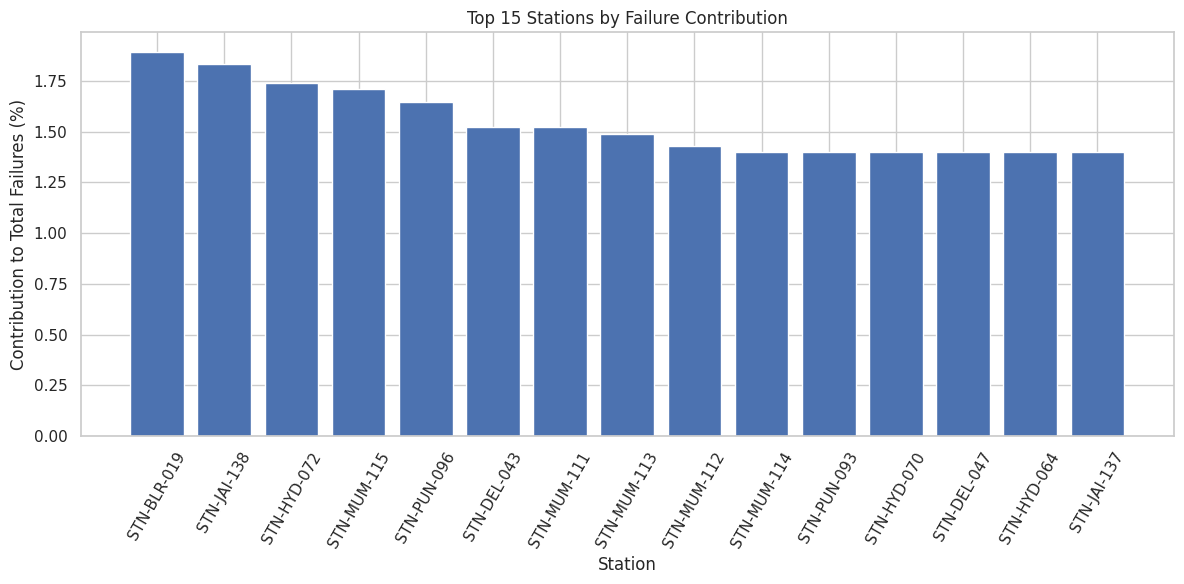

In [103]:
# Step 15: Top 15 Stations — Failure Contribution

top_15_stations = station_failures.head(15)

plt.figure(figsize=(12, 6))
plt.bar(
    top_15_stations["station_id"],
    top_15_stations["failure_contribution_pct"]
)

plt.title("Top 15 Stations by Failure Contribution")
plt.xlabel("Station")
plt.ylabel("Contribution to Total Failures (%)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [104]:
# Step 16: Failure Type by Station

failure_type_station = swap_events[
    swap_events["event_type"] != "swap_completed"
].groupby(
    ["station_id", "event_type"]
).size().unstack(
    fill_value=0
).reset_index()

failure_type_station.head(15)

event_type,station_id,abandoned_queue,cancelled_by_rider,failed_no_charged_battery,failed_system_error
0,STN-BLR-001,8,0,10,1
1,STN-BLR-002,13,0,13,3
2,STN-BLR-003,10,2,28,2
3,STN-BLR-004,12,4,22,4
4,STN-BLR-005,7,2,17,1
5,STN-BLR-006,3,1,15,0
6,STN-BLR-007,6,7,15,1
7,STN-BLR-008,16,3,19,3
8,STN-BLR-009,13,4,19,5
9,STN-BLR-010,8,1,21,1


In [105]:
# Step 17: Overall Failure Type Contribution

failure_type_summary = swap_events[
    swap_events["event_type"] != "swap_completed"
]["event_type"].value_counts().reset_index()

failure_type_summary.columns = [
    "failure_type",
    "failed_attempts"
]

failure_type_summary["failure_contribution_pct"] = (
    failure_type_summary["failed_attempts"]
    / failure_type_summary["failed_attempts"].sum() * 100
)

failure_type_summary

,failure_type,failed_attempts,failure_contribution_pct
0,failed_no_charged_battery,1785,55.43
1,abandoned_queue,918,28.51
2,cancelled_by_rider,307,9.53
3,failed_system_error,210,6.52


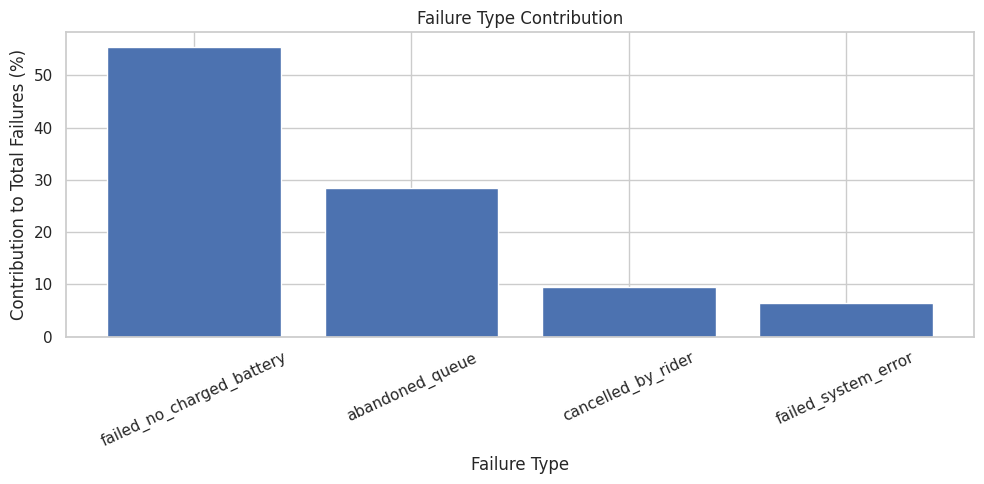

In [106]:
# Step 18: Failure Type Distribution Chart

plt.figure(figsize=(10, 5))

plt.bar(
    failure_type_summary["failure_type"],
    failure_type_summary["failure_contribution_pct"]
)

plt.title("Failure Type Contribution")
plt.xlabel("Failure Type")
plt.ylabel("Contribution to Total Failures (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Key Finding

Failure analysis shows that service issues are not concentrated only in a small number of stations. The top 15 stations account for 22.25% of total failed attempts, indicating that reliability issues are distributed across the network.

The dominant failure type is `failed_no_charged_battery`, accounting for 55.09% of all failures. `abandoned_queue` contributes another 29.21%. Together, these two categories represent 84.30% of observed failures.

### Business Implication

The evidence points toward battery availability and queue management as the primary operational areas for failure reduction.

Rather than focusing only on a small group of underperforming stations, VoltRelay should investigate network-wide battery availability, station inventory balancing, charging turnaround, and peak-period queue management. High-failure stations can then be used as targeted diagnostic cases.

## 16. Cross-Functional Findings

The analysis across network operations, service quality, stations, batteries, pricing, fleet partners, and rider retention reveals several connected business patterns:

1. **Network activity and revenue**
   - Completed swaps and revenue increased through March 2024 in the available data.
   - The April failure rate increased to 6.74%.
   - The energy-cost-based margin proxy remained relatively stable.

2. **Service reliability**
   - Service failures vary across stations and cities.
   - 3W transactions show a higher failure rate of 9.26% compared with 4.00% for 2W transactions.
   - Capacity groups show very similar failure rates, suggesting that capacity alone does not explain service reliability.

3. **Failure concentration**
   - The top 15 stations contribute 22.25% of total failed attempts.
   - Therefore, failures are distributed across the wider network rather than being concentrated only in a few stations.
   - `failed_no_charged_battery` represents 55.09% of failures, while `abandoned_queue` represents 29.21%.

4. **Battery performance**
   - Battery health varies substantially across suppliers and manufacturing lots.
   - Kyron batteries show lower average current SOH than Amptek and Cellora.
   - Several low-performing manufacturing lots are concentrated within Kyron.

5. **Pricing and partner economics**
   - PARTNER transactions receive an average discount of 10.40%, compared with no discount for STD transactions.
   - Partner segments other than cargo_3w show similar completion rates.
   - Cargo_3w has a lower completion rate of 90.75%.

6. **Rider retention**
   - Vehicle class, signup channel, and plan type show relatively small retention differences.
   - City retention ranges from 79.46% to 84.01%.
   - Riders with higher failure rates show substantially lower observed retention.
   - This association should not be interpreted as proof of causation.

Overall, the evidence indicates that operational reliability, battery availability, and equipment health are more prominent areas for investigation than simple capacity expansion or plan-level changes.

## 17. Key Business Insights

### Insight 1 — Service reliability is a major operational concern

The available network data shows an increase in failure rate to 6.74% in April 2024, while average queue wait remained broadly stable. This indicates that higher failure rates cannot be explained by queue time alone.

### Insight 2 — Battery availability is the dominant failure category

`failed_no_charged_battery` accounts for 55.09% of all failed attempts. Combined with abandoned queues, these two categories represent 84.30% of failures.

This makes battery availability, charging turnaround, and inventory balancing important operational priorities.

### Insight 3 — 3W operations require additional attention

3W transactions have a 9.26% failure rate compared with 4.00% for 2W transactions. This is one of the clearest operational differences identified in the analysis.

### Insight 4 — Battery health varies by supplier and manufacturing lot

Kyron batteries show substantially lower average current SOH than Amptek and Cellora. Several of the lowest-performing manufacturing lots are also associated with Kyron.

This suggests that battery lifecycle monitoring should be performed at supplier and lot level.

### Insight 5 — Capacity alone does not explain station failure rates

Low-, medium-, and high-capacity station groups show very similar failure rates, ranging from approximately 4.60% to 4.65%.

Therefore, simply increasing station capacity may not address the underlying reliability problem.

### Insight 6 — Rider retention is associated with service reliability

Riders with failure rates above 10% show a 58.97% observed retention rate, compared with 95.76% among riders with a 1–5% failure rate.

This relationship should be treated as an association rather than a causal conclusion.

### Insight 7 — Pricing and partner economics require segment-level evaluation

PARTNER transactions receive an average discount of 10.40%, but their higher transaction volume generates substantially more revenue than STD transactions.

Cargo_3w partners show a lower completion rate of 90.75%, indicating a need to investigate their operating requirements separately.

### Overall Business Insight

The strongest evidence points toward improving operational reliability before relying on broad capacity expansion or pricing changes. Battery availability, charging turnaround, 3W service requirements, and low-SOH battery cohorts provide the most actionable areas for further investigation.

## 18. Actionable Recommendations

### Recommendation 1 — Improve Battery Availability

**Finding:** `failed_no_charged_battery` accounts for 55.09% of all failures.

**Action:** Implement station-level inventory monitoring and rebalance charged batteries toward stations with recurring shortages, especially during high-demand periods.

**KPI to Monitor:**
- Failed-no-charged-battery rate
- Charged battery availability
- Battery turnaround time
- Station-level failure rate

---

### Recommendation 2 — Improve 3W Service Operations

**Finding:** 3W transactions have a 9.26% failure rate compared with 4.00% for 2W.

**Action:** Analyze 3W demand patterns separately and review inventory targets, charging capacity, and queue management at stations serving high 3W volumes.

**KPI to Monitor:**
- 3W failure rate
- 3W queue wait time
- 3W battery availability
- 3W completed swaps per station

---

### Recommendation 3 — Monitor Battery Suppliers and Manufacturing Lots

**Finding:** Kyron batteries show lower current SOH, with several low-performing manufacturing lots around 60–61% current SOH.

**Action:** Establish supplier- and lot-level battery health monitoring and investigate degradation, usage intensity, and retirement patterns before future procurement decisions.

**KPI to Monitor:**
- Average current SOH
- SOH degradation rate
- Battery retirement rate
- Swaps per battery
- Supplier/lot-level failure indicators

---

### Recommendation 4 — Use Targeted Station Diagnostics

**Finding:** The top 15 stations account for 22.25% of failures, meaning failures are distributed across the network.

**Action:** Use high-failure stations as diagnostic cases while simultaneously monitoring network-wide operational factors such as inventory availability and charging turnaround.

**KPI to Monitor:**
- Station failure rate
- Failure contribution
- Outage minutes
- Average charging time
- Quarantined battery count

---

### Recommendation 5 — Investigate Retention Through Service Reliability

**Finding:** Riders with higher failure rates show substantially lower observed retention.

**Action:** Create a rider-experience monitoring framework that flags repeated failed attempts and evaluates whether service recovery actions improve subsequent usage.

**KPI to Monitor:**
- Rider-level failure rate
- Repeat swap rate
- 30-day retention
- Abandoned queue rate
- Failed attempts per rider

---

### Recommendation 6 — Evaluate Partner Pricing Alongside Service Performance

**Finding:** PARTNER transactions receive discounts, while cargo_3w partners show a lower completion rate of 90.75%.

**Action:** Evaluate partner economics using revenue, discount, completion rate, and operational requirements together rather than optimizing price alone.

**KPI to Monitor:**
- Revenue per swap
- Discount per swap
- Completion rate
- Failure rate by partner
- Partner contribution margin proxy

## 19. Conclusion

The analysis evaluated VoltRelay Energy's network performance, service reliability, station operations, battery health, pricing, fleet partner economics, and rider retention.

The strongest evidence points toward operational reliability as a key area for improvement. Battery availability is the largest observed failure category, while 3W transactions show a substantially higher failure rate than 2W transactions.

Battery analysis also identified meaningful differences across suppliers and manufacturing lots, indicating the need for more granular lifecycle monitoring.

From a commercial perspective, partner transactions generate significant revenue despite discounts, while cargo_3w partners show comparatively lower completion rates. Pricing decisions should therefore be evaluated together with service performance and partner economics.

Rider-level analysis shows an association between repeated service failures and lower observed retention. However, the available data is observational and the retention metric is subject to the available observation window, so these findings should be treated as evidence for further investigation rather than causal conclusions.

Overall, the analysis supports a business focus on:

- Improving charged-battery availability
- Reducing repeated service failures
- Strengthening 3W operational support
- Monitoring battery suppliers and manufacturing lots
- Using station-level diagnostics
- Connecting operational reliability with rider retention
- Evaluating pricing and partner economics together

These actions provide a data-driven framework for improving network reliability, customer experience, and operational efficiency.

In [107]:
# Step 24: Final Data & KPI Validation

print("Dataset Shapes:")
print("Swap Events:", swap_events.shape)
print("Station Hourly:", station_hourly.shape)
print("Riders:", riders.shape)
print("Batteries:", batteries.shape)
print("Support Tickets:", support_tickets.shape)
print("Stations:", stations.shape)
print("City Context:", city_context.shape)
print("Fleet Partners:", fleet_partners.shape)

print("\nKey KPI Checks:")
print("Total Attempts:", len(swap_events))
print(
    "Completed Swaps:",
    (swap_events["event_type"] == "swap_completed").sum()
)
print(
    "Failed Attempts:",
    (swap_events["event_type"] != "swap_completed").sum()
)
print(
    "Overall Failure Rate:",
    round(
        (swap_events["event_type"] != "swap_completed").mean() * 100,
        2
    ),
    "%"
)

Dataset Shapes:
Swap Events: (72519, 24)
Station Hourly: (100647, 14)
Riders: (20000, 12)
Batteries: (6500, 13)
Support Tickets: (21104, 12)
Stations: (152, 22)
City Context: (3282, 12)
Fleet Partners: (12, 12)

Key KPI Checks:
Total Attempts: 72519
Completed Swaps: 69299
Failed Attempts: 3220
Overall Failure Rate: 4.44 %


In [108]:
# Step 25: Final Date Range & Missing Values Check

print("Swap Event Date Range:")
print(swap_events["event_ts"].min())
print(swap_events["event_ts"].max())

print("\nMissing Values in Key Analysis Tables:")
print("Swap Events:", swap_events.isna().sum().sum())
print("Riders:", riders.isna().sum().sum())
print("Batteries:", batteries.isna().sum().sum())
print("Stations:", stations.isna().sum().sum())

print("\nDuplicate Rows:")
print("Swap Events:", swap_events.duplicated().sum())
print("Riders:", riders.duplicated().sum())
print("Batteries:", batteries.duplicated().sum())
print("Stations:", stations.duplicated().sum())

Swap Event Date Range:
2024-01-01 00:00:33
2024-01-21 23:50:19

Missing Values in Key Analysis Tables:
Swap Events: 14962
Riders: 12837
Batteries: 10124
Stations: 293

Duplicate Rows:
Swap Events: 0
Riders: 0
Batteries: 0
Stations: 0


## 20. Analysis Limitations & Assumptions

- The available `swap_events` data covers 1 January 2024 to 8 April 2024. Therefore, time-based conclusions are limited to the available observation period.
- The analysis is based on observational data. Observed associations should not be interpreted as causal relationships.
- Contribution margin is represented using an energy-cost-based margin proxy and does not include all operating costs such as rent, maintenance, staffing, or other overheads.
- Missing values were retained where appropriate because missingness can itself contain operational information.
- Invalid SOC, SOH, and distance observations were not removed blindly; they were considered during analysis based on business context.
- City names were standardized before city-level comparisons.
- The 30-day retention analysis is subject to right-censoring because some riders may not have had a full 30-day observation window.
- Support-ticket presence is treated as an observed association with retention and not as evidence that support interactions improve retention.
- The dataset contains synthetic business data, so findings should be interpreted within the scope of the hackathon dataset.